In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, glob, os, torch
from pathlib import Path

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {
    "Mean":    "#4C72B0",
    "DeepSets":"#DD8452",
    "SetTransf":"#55A868",
    "Ranking": "#C44E52",
}
DATASETS = ["animals", "carcinogenesis", "family",
            "lymphography", "mutagenesis", "nctrer"]
DATASET_LABELS = {
    "animals":       "Animals",
    "carcinogenesis":"Carcinogenesis",
    "family":        "Family",
    "lymphography":  "Lymphography",
    "mutagenesis":   "Mutagenesis",
    "nctrer":        "Nctrer",
}
ROOT = Path(".")

# ── Load regression (BS) results ────────────────────────────────────────────
bs_dfs = []
for ds in DATASETS:
    f = ROOT / "results" / f"{ds}_results.csv"
    if f.exists():
        df = pd.read_csv(f)
        df["dataset"] = ds
        bs_dfs.append(df)
bs = pd.concat(bs_dfs, ignore_index=True)

AGG_MAP = {
    "V-Net [mean / bootstrap]":           "Mean",
    "V-Net [deepsets / bootstrap]":        "DeepSets",
    "V-Net [settransformer / bootstrap]":  "SetTransf",
}
bs["model"] = bs["agg_method"].map(AGG_MAP)
bs["variant"] = "VOCELL-BS"

# ── Load ranking (RK) results ───────────────────────────────────────────────
rk_dfs = []
for ds in DATASETS:
    f = ROOT / "results_ranking" / f"{ds}_results.csv"
    if f.exists():
        df = pd.read_csv(f)
        df["dataset"] = ds
        rk_dfs.append(df)
rk = pd.concat(rk_dfs, ignore_index=True)
rk["model"] = "Ranking"
rk["variant"] = "VOCELL-RK"

# ── Combined ────────────────────────────────────────────────────────────────
all_df = pd.concat([bs, rk], ignore_index=True)
all_df["dataset_label"] = all_df["dataset"].map(DATASET_LABELS)

print(f"VOCELL-BS rows : {len(bs):,}  "
      f"| VOCELL-RK rows : {len(rk):,}  "
      f"| Total : {len(all_df):,}")
print("\nVOCELL-BS model counts:\n", bs["model"].value_counts().to_string())


VOCELL-BS rows : 3,027  | VOCELL-RK rows : 909  | Total : 3,936

VOCELL-BS model counts:
 model
Mean         1059
DeepSets     1059
SetTransf     909


## 1 · Model Size Comparison

Detected embedding_dim = 256
Initializing SetTransformerAggregator with dim=256 and num_heads=4
Drill:  33,563,041 params  (134.26 MB)
DrillV: 594,177 params  (2.38 MB)


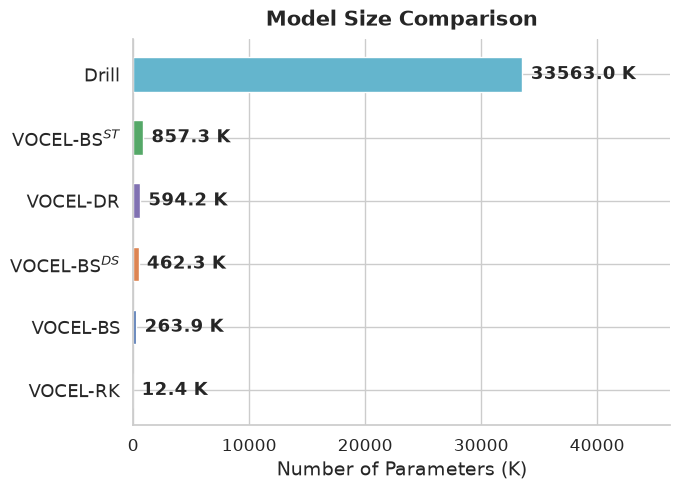


Architecture summary (corrected, h=1×emb_dim for VOCELL):
          Label  Params_K    Size_MB
       VOCEL-RK      12.4   0.064938
       VOCEL-BS     263.9   2.124176
VOCEL-BS$^{DS}$     462.3   1.869850
       VOCEL-DR     594.2   2.382386
VOCEL-BS$^{ST}$     857.3   3.451889
          Drill   33563.0 134.255090


In [5]:
import sys, glob as _glob
sys.path.insert(0, str(ROOT))
from concept_aggregators import ConceptVNet

CKPT_PATTERNS = {
    "Mean":     ("{ds}_mean/vocell_v_net_bootstrap_mean.pt",
                 lambda ds: ds.capitalize()),
    "DeepSets": ("{ds}_DS/vocell_v_net_bootstrap_deepsets.pt",
                 lambda ds: ds.capitalize()),
    "SetTransf":("{ds}_ST/vocell_v_net_bootstrap_settransformer.pt",
                 lambda ds: ds.capitalize()),
    "Ranking":  ("{ds}_ranking/vocell_v_net_bootstrap_ranking_large.pt",
                 lambda ds: ds.capitalize()),
}
CKPT_OVERRIDES = {
    ("Family", "Ranking"): "Family_ranking/vocell_v_net_bootstrap_ranking_large.pt",
}

# ── Infer embedding_dim from the first available Mean checkpoint ─────────────
_emb_dim = None
for ds in DATASETS:
    p = ROOT / f"{DATASET_LABELS[ds]}_mean/vocell_v_net_bootstrap_mean.pt"
    if p.exists():
        _raw = torch.load(str(p), map_location="cpu", weights_only=False)
        _sd  = _raw.get("model_state_dict", _raw) if isinstance(_raw, dict) else _raw
        _w   = next(v for v in _sd.values() if hasattr(v, "shape") and v.ndim == 2)
        _emb_dim = _w.shape[1] // 3
        break
print(f"Detected embedding_dim = {_emb_dim}")

# ── Corrected parameter counts via ConceptVNet (h=1×emb_dim for all BS) ──────
CORRECTED_AGG_PARAMS = {}
for agg_type, label in [("mean","Mean"), ("deepsets","DeepSets"), ("settransformer","SetTransf")]:
    m = ConceptVNet(_emb_dim, agg_type, device="cpu")
    CORRECTED_AGG_PARAMS[label] = sum(p.numel() for p in m.parameters())

# ── Load corrected BS + Ranking sizes from disk ───────────────────────────────
size_rows = []
for ds in DATASETS:
    DS = DATASET_LABELS[ds]
    for model_name, (pattern, cap_fn) in CKPT_PATTERNS.items():
        path = ROOT / pattern.format(ds=cap_fn(ds))
        key  = (DS, model_name)
        if key in CKPT_OVERRIDES:
            path = ROOT / CKPT_OVERRIDES[key]
        if not path.exists():
            continue
        raw   = torch.load(str(path), map_location="cpu", weights_only=False)
        sd    = raw.get("model_state_dict", raw) if isinstance(raw, dict) else {}
        size_mb = path.stat().st_size / 1e6
        corrected = (CORRECTED_AGG_PARAMS.get(model_name, 0)
                     if model_name != "Ranking"
                     else sum(v.numel() for v in sd.values() if hasattr(v, "numel")))
        size_rows.append({"Dataset": DS, "Model": model_name,
                          "Parameters": corrected, "Size_MB": size_mb})

size_df = pd.DataFrame(size_rows)

# ── Drill: compute from any DrillHeuristic_averaging checkpoint ───────────────
_drill_ckpts = sorted(_glob.glob(str(ROOT / "Log" / "*" / "DrillHeuristic_averaging.pth")))
if _drill_ckpts:
    _dr_raw = torch.load(_drill_ckpts[0], map_location="cpu", weights_only=False)
    _dr_sd  = (_dr_raw.get("model_state_dict", _dr_raw.get("state_dict", _dr_raw))
               if isinstance(_dr_raw, dict) else _dr_raw)
    _dr_params  = sum(v.numel() for v in _dr_sd.values() if hasattr(v, "numel"))
    _dr_size_mb = Path(_drill_ckpts[0]).stat().st_size / 1e6
    for ds in DATASETS:
        size_rows.append({"Dataset": DATASET_LABELS[ds], "Model": "Drill",
                          "Parameters": _dr_params, "Size_MB": _dr_size_mb})
    print(f"Drill:  {_dr_params:,} params  ({_dr_size_mb:.2f} MB)")

# ── DrillV: compute from any DrillV_Complex checkpoint ───────────────────────
_drillv_ckpts = sorted(_glob.glob(str(ROOT / "Log" / "*" / "DrillV_Complex.pth")))
if _drillv_ckpts:
    _dv_raw = torch.load(_drillv_ckpts[0], map_location="cpu", weights_only=False)
    _dv_sd  = (_dv_raw.get("model_state_dict", _dv_raw.get("state_dict", _dv_raw))
               if isinstance(_dv_raw, dict) else _dv_raw)
    _dv_params  = sum(v.numel() for v in _dv_sd.values() if hasattr(v, "numel"))
    _dv_size_mb = Path(_drillv_ckpts[0]).stat().st_size / 1e6
    for ds in DATASETS:
        size_rows.append({"Dataset": DATASET_LABELS[ds], "Model": "DrillV",
                          "Parameters": _dv_params, "Size_MB": _dv_size_mb})
    print(f"DrillV: {_dv_params:,} params  ({_dv_size_mb:.2f} MB)")

size_df = pd.DataFrame(size_rows)

# ── One row per architecture, sorted by param count ──────────────────────────
arch_size = (size_df.groupby("Model")[["Parameters","Size_MB"]]
             .first().reset_index()
             .sort_values("Parameters"))
arch_size["Params_K"] = (arch_size["Parameters"] / 1e3).round(1)

DISPLAY_NAMES = {
    "Ranking":  "VOCEL-RK",
    "DrillV":   "VOCEL-DR",
    "Mean":     "VOCEL-BS",
    "DeepSets": r"VOCEL-BS$^{DS}$",
    "SetTransf":r"VOCEL-BS$^{ST}$",
    "Drill":    "Drill",
}
arch_size["Label"] = arch_size["Model"].map(DISPLAY_NAMES)
arch_size = arch_size.sort_values("Params_K")

# ── Paper-ready plot ──────────────────────────────────────────────────────────
PAPER_PALETTE = {
    "Mean":     PALETTE["Mean"],
    "DeepSets": PALETTE["DeepSets"],
    "SetTransf":PALETTE["SetTransf"],
    "Ranking":  PALETTE["Ranking"],
    "DrillV":   "#8172B2",
    "Drill":    "#64B5CD",
}

n_models = len(arch_size)
fig, ax = plt.subplots(figsize=(7, 0.65 * n_models + 1.2))
colors = [PAPER_PALETTE[m] for m in arch_size["Model"]]
bars   = ax.barh(arch_size["Label"], arch_size["Params_K"],
                 color=colors, edgecolor="white", height=0.55)
ax.bar_label(bars, fmt="%.1f K", padding=6, fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Parameters (K)", fontsize=14)
ax.set_xlim(0, arch_size["Params_K"].max() * 1.38)
ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", labelsize=12)
ax.set_title("Model Size Comparison", fontsize=15, fontweight="bold", pad=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("results_analysis_model_sizes.pdf", dpi=300, bbox_inches="tight")
plt.savefig("results_analysis_model_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nArchitecture summary (corrected, h=1×emb_dim for VOCELL):")
print(arch_size[["Label","Params_K","Size_MB"]].to_string(index=False))


## 2 · Training Loss Curves

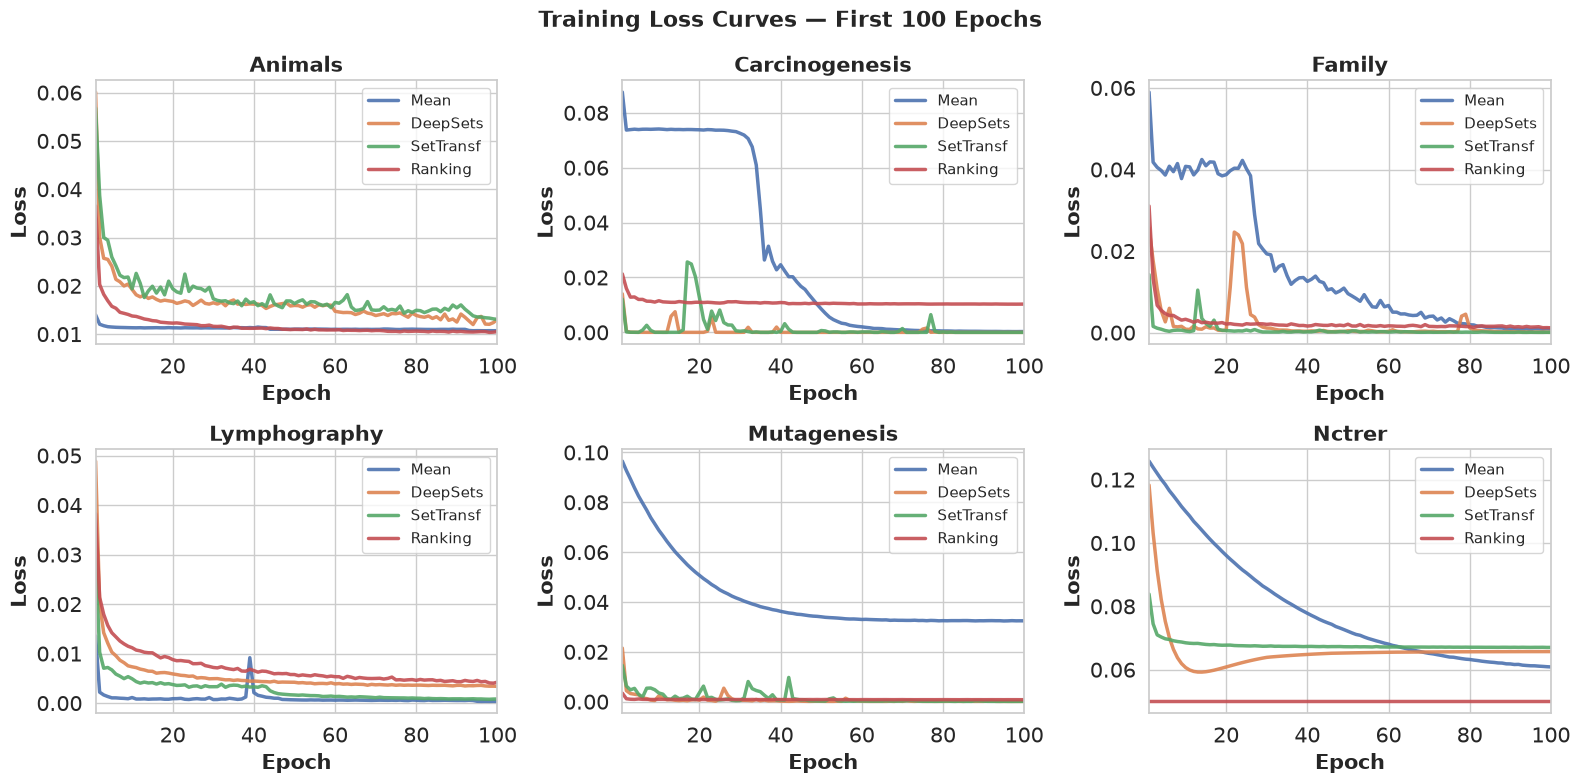

In [3]:
LOSS_PATTERNS = {
    "Mean":     "{ds}_mean/vocell_v_net_bootstrap_mean_loss.json",
    "DeepSets": "{ds}_DS/vocell_v_net_bootstrap_deepsets_loss.json",
    "SetTransf":"{ds}_ST/vocell_v_net_bootstrap_settransformer_loss.json",
    "Ranking":  "{ds}_ranking/vocell_v_net_bootstrap_ranking_large_loss.json",
}

MAX_EPOCHS = 100

def load_losses(path, max_epochs=MAX_EPOCHS):
    """Load a loss JSON file. Handles both a plain list of floats
    and a list of dicts (e.g. [{'loss': 0.5, ...}, ...])."""
    raw = json.loads(Path(path).read_text())
    if not raw:
        return []
    if isinstance(raw[0], dict):
        key = next((k for k in ["loss", "val_loss", "train_loss", "value"]
                    if k in raw[0]), None)
        if key is None:
            key = next(k for k, v in raw[0].items() if isinstance(v, (int, float)))
        losses = [d[key] for d in raw]
    else:
        losses = [float(v) for v in raw]
    return losses[:max_epochs]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for ax, ds in zip(axes, DATASETS):
    DS = DATASET_LABELS[ds]
    for model, pattern in LOSS_PATTERNS.items():
        path = ROOT / pattern.format(ds=DS)
        if not path.exists():
            continue
        losses = load_losses(path)
        epochs = list(range(1, len(losses) + 1))
        ax.plot(epochs, losses, label=model, color=PALETTE[model],
                linewidth=2.5, alpha=0.9)
    ax.set_title(DS, fontsize=15, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=15, fontweight="bold")
    ax.set_ylabel("Loss", fontsize=15, fontweight="bold")
    ax.set_xlim(1, MAX_EPOCHS)
    ax.tick_params(axis="both", labelsize=15)
    ax.legend(fontsize=11, loc="upper right")

fig.suptitle(f"Training Loss Curves — First {MAX_EPOCHS} Epochs", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("results_analysis_loss_curves.pdf", dpi=300, bbox_inches="tight")
plt.savefig("results_analysis_loss_curves.png", dpi=300, bbox_inches="tight")

plt.show()


## 3 · Per-Dataset F1 Performance — All Models

/tmp/ipykernel_3073556/142362161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="model", y="f1", palette=PALETTE,
/tmp/ipykernel_3073556/142362161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="model", y="f1", palette=PALETTE,
/tmp/ipykernel_3073556/142362161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="model", y="f1", palette=PALETTE,
/tmp/ipykernel_3073556/142362161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

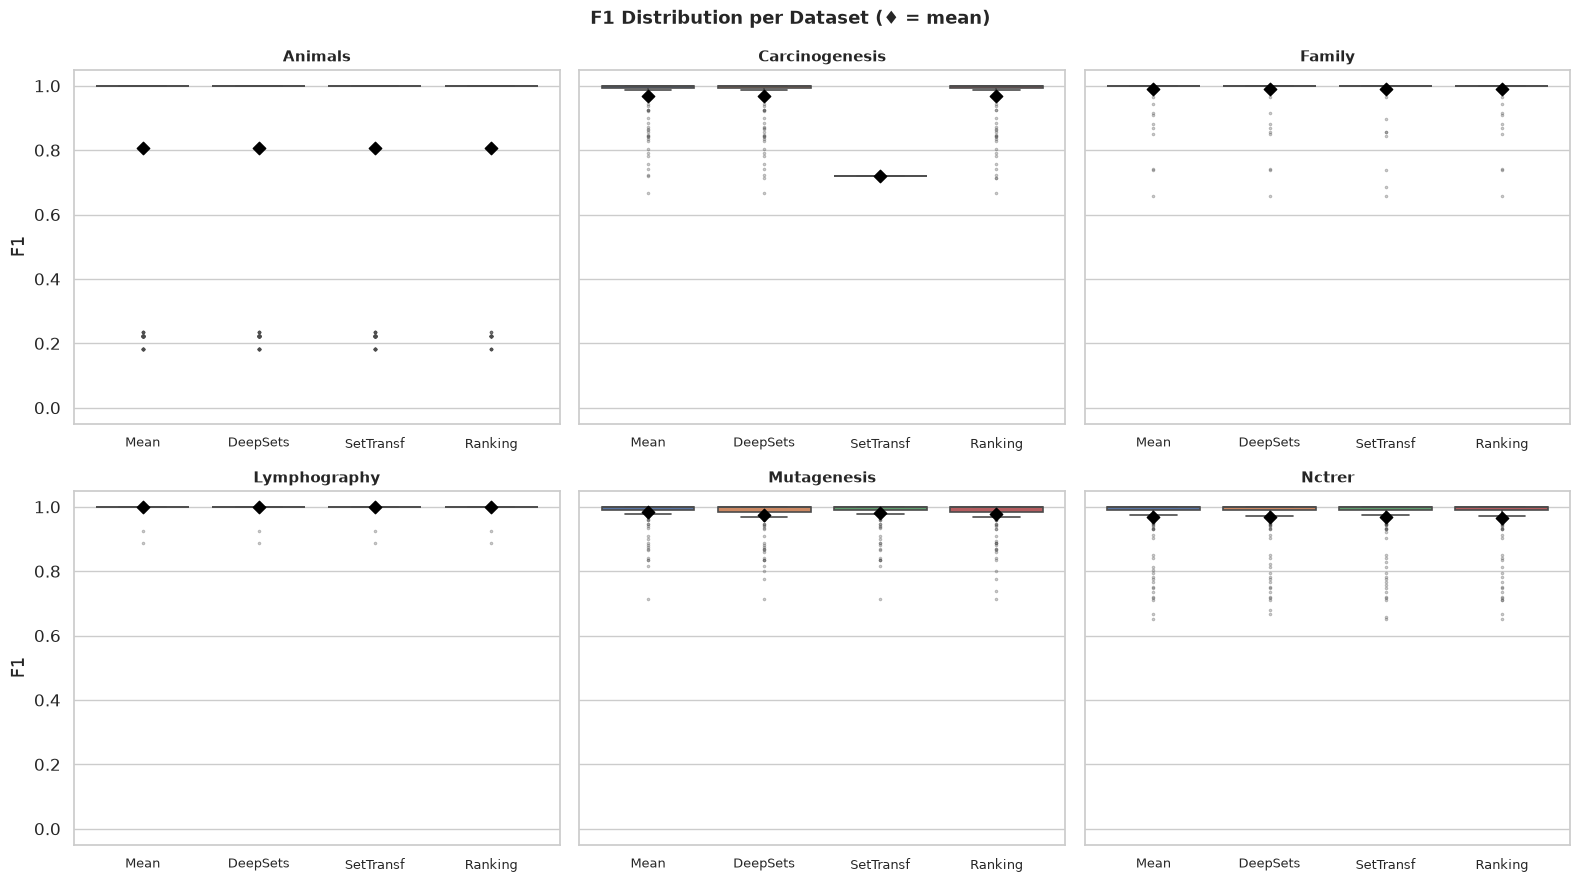

In [6]:
MODEL_ORDER = ["Mean", "DeepSets", "SetTransf", "Ranking"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, ds in zip(axes, DATASETS):
    sub = all_df[all_df["dataset"] == ds].copy()
    sub["model"] = pd.Categorical(sub["model"], categories=MODEL_ORDER, ordered=True)
    sub = sub.sort_values("model")

    sns.boxplot(data=sub, x="model", y="f1", palette=PALETTE,
                order=MODEL_ORDER, ax=ax, linewidth=1.2,
                flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("F1" if ax is axes[0] or ax is axes[3] else "")
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", labelsize=9)
    # Add mean as diamond
    means = sub.groupby("model", observed=True)["f1"].mean()
    for i, m in enumerate(MODEL_ORDER):
        if m in means.index:
            ax.scatter(i, means[m], marker="D", s=40, color="black", zorder=5)

fig.suptitle("F1 Distribution per Dataset (♦ = mean)", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("results_analysis_f1_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · Mean F1 Heatmap — Model × Dataset

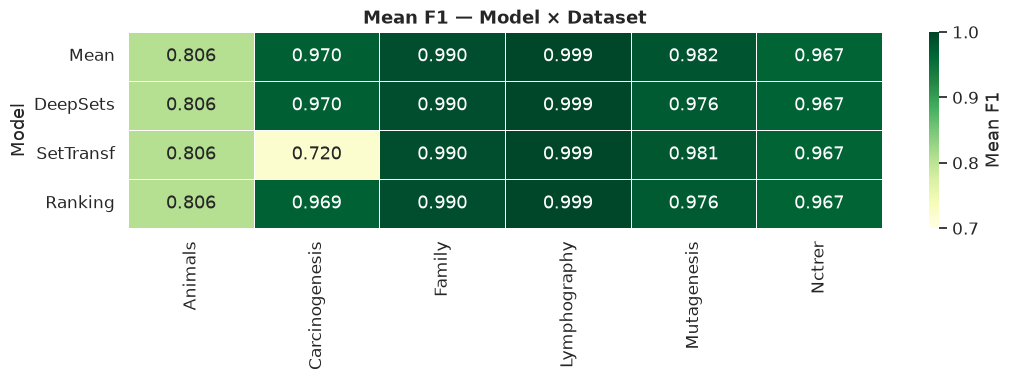

dataset    Animals  Carcinogenesis  Family  Lymphography  Mutagenesis  Nctrer
model                                                                        
Mean        0.8063          0.9698  0.9902        0.9985       0.9823  0.9670
DeepSets    0.8063          0.9698  0.9902        0.9985       0.9760  0.9674
SetTransf   0.8063          0.7200  0.9903        0.9985       0.9808  0.9671
Ranking     0.8063          0.9688  0.9902        0.9985       0.9765  0.9667


In [7]:
pivot = (all_df.groupby(["model", "dataset"])["f1"]
         .mean()
         .unstack("dataset")
         .reindex(MODEL_ORDER)
         .rename(columns=DATASET_LABELS))

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
            vmin=0.7, vmax=1.0, linewidths=0.5,
            cbar_kws={"label": "Mean F1"}, ax=ax)
ax.set_title("Mean F1 — Model × Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("results_analysis_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(pivot.round(4).to_string())


## 5 · Runtime Comparison — Mean Inference Time per LP

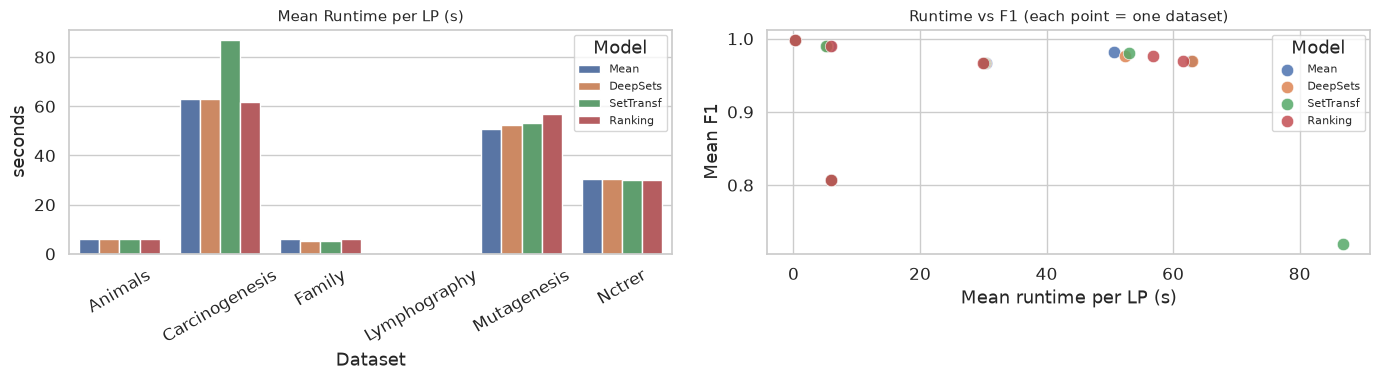


Mean runtime (s) per model per dataset:
dataset    Animals  Carcinogenesis  Family  Lymphography  Mutagenesis  Nctrer
model                                                                        
Mean          5.91           62.77    5.84          0.20        50.72   30.46
DeepSets      5.89           63.02    5.37          0.19        52.45   30.31
SetTransf     5.87           86.85    5.19          0.19        53.04   30.13
Ranking       5.92           61.62    5.86          0.19        56.88   29.99


In [8]:
rt_pivot = (all_df.groupby(["model", "dataset"])["runtime_s"]
            .mean()
            .unstack("dataset")
            .reindex(MODEL_ORDER)
            .rename(columns=DATASET_LABELS))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Grouped bar per dataset
rt_plot = rt_pivot.T.reset_index().melt(id_vars="dataset", var_name="Model", value_name="Runtime_s")
rt_plot["Model"] = pd.Categorical(rt_plot["Model"], MODEL_ORDER, ordered=True)
sns.barplot(data=rt_plot, x="dataset", y="Runtime_s", hue="Model",
            palette=PALETTE, hue_order=MODEL_ORDER, ax=axes[0])
axes[0].set_title("Mean Runtime per LP (s)", fontsize=11)
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("seconds")
axes[0].legend(title="Model", fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

# Runtime vs F1 scatter (mean per dataset×model)
rt_f1 = (all_df.groupby(["model","dataset"])
         .agg(mean_f1=("f1","mean"), mean_rt=("runtime_s","mean"))
         .reset_index())
for model in MODEL_ORDER:
    sub = rt_f1[rt_f1["model"] == model]
    axes[1].scatter(sub["mean_rt"], sub["mean_f1"], label=model,
                    color=PALETTE[model], s=80, alpha=0.85, edgecolors="white", linewidths=0.5)
axes[1].set_xlabel("Mean runtime per LP (s)")
axes[1].set_ylabel("Mean F1")
axes[1].set_title("Runtime vs F1 (each point = one dataset)", fontsize=11)
axes[1].legend(title="Model", fontsize=8)

plt.tight_layout()
# plt.savefig("results_analysis_runtime.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMean runtime (s) per model per dataset:")
print(rt_pivot.round(2).to_string())


## 6 · F1=1.0 Rate & Concepts Explored

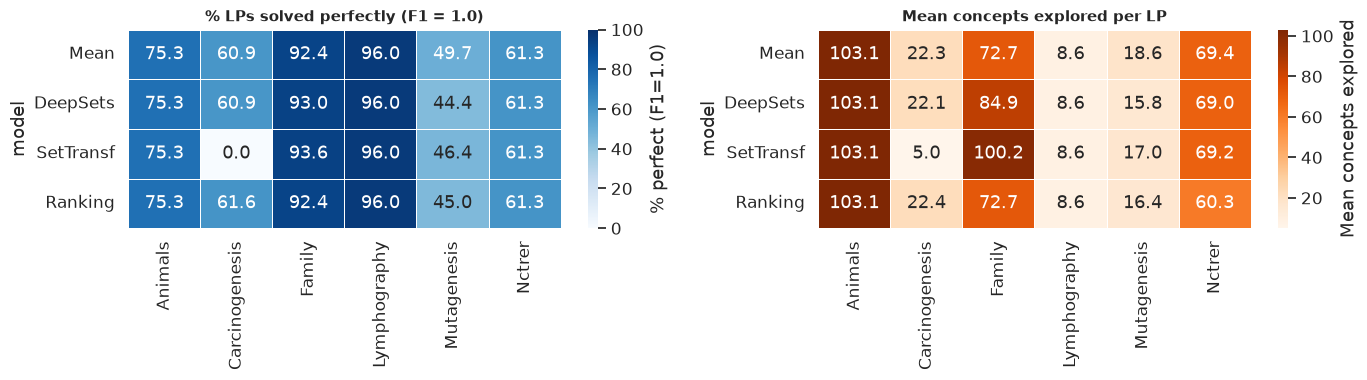

Perfect F1 rate (%):
dataset    Animals  Carcinogenesis  Family  Lymphography  Mutagenesis  Nctrer
model                                                                        
Mean          75.3            60.9    92.4          96.0         49.7    61.3
DeepSets      75.3            60.9    93.0          96.0         44.4    61.3
SetTransf     75.3             0.0    93.6          96.0         46.4    61.3
Ranking       75.3            61.6    92.4          96.0         45.0    61.3

Mean concepts explored:
dataset    Animals  Carcinogenesis  Family  Lymphography  Mutagenesis  Nctrer
model                                                                        
Mean         103.1            22.3    72.7           8.6         18.6    69.4
DeepSets     103.1            22.1    84.9           8.6         15.8    69.0
SetTransf    103.1             5.0   100.2           8.6         17.0    69.2
Ranking      103.1            22.4    72.7           8.6         16.4    60.3


In [9]:
all_df["perfect"] = (all_df["f1"] == 1.0).astype(float)

perfect_pivot = (all_df.groupby(["model","dataset"])["perfect"]
                 .mean().mul(100)
                 .unstack("dataset")
                 .reindex(MODEL_ORDER)
                 .rename(columns=DATASET_LABELS))

concepts_pivot = (all_df.groupby(["model","dataset"])["concepts_explored"]
                  .mean()
                  .unstack("dataset")
                  .reindex(MODEL_ORDER)
                  .rename(columns=DATASET_LABELS))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(perfect_pivot, annot=True, fmt=".1f", cmap="Blues",
            vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={"label": "% perfect (F1=1.0)"}, ax=axes[0])
axes[0].set_title("% LPs solved perfectly (F1 = 1.0)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")

sns.heatmap(concepts_pivot, annot=True, fmt=".1f", cmap="Oranges",
            linewidths=0.5,
            cbar_kws={"label": "Mean concepts explored"}, ax=axes[1])
axes[1].set_title("Mean concepts explored per LP", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")

plt.tight_layout()
# plt.savefig("results_analysis_perfect_concepts.png", dpi=150, bbox_inches="tight")
plt.show()

print("Perfect F1 rate (%):")
print(perfect_pivot.round(1).to_string())
print("\nMean concepts explored:")
print(concepts_pivot.round(1).to_string())


## 7 · Aggregation Strategy Comparison: BS-Mean vs BS-DeepSets vs BS-SetTransf

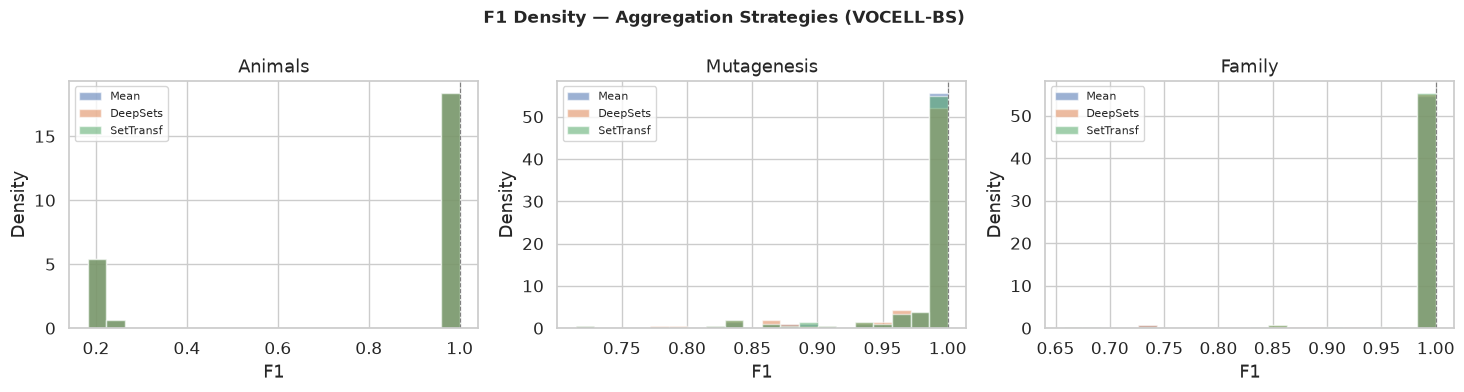

VOCELL-BS aggregation global summary:
           Mean F1  Median F1  Std F1  Perfect (%)
model                                             
DeepSets    0.9311        1.0  0.2023      72.4268
Mean        0.9320        1.0  0.2022      73.0878
SetTransf   0.9253        1.0  0.2161      74.6975


In [10]:
bs_only = all_df[all_df["variant"] == "VOCELL-BS"].copy()

# Overall F1 distribution per aggregation across all datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ds in zip(axes, ["animals", "mutagenesis", "family"]):
    sub = bs_only[bs_only["dataset"] == ds]
    for model in ["Mean", "DeepSets", "SetTransf"]:
        vals = sub[sub["model"] == model]["f1"].dropna()
        ax.hist(vals, bins=20, alpha=0.55, label=model,
                color=PALETTE[model], density=True, edgecolor="white")
    ax.axvline(1.0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(DATASET_LABELS[ds])
    ax.set_xlabel("F1")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("F1 Density — Aggregation Strategies (VOCELL-BS)", fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("results_analysis_agg_hist.png", dpi=150, bbox_inches="tight")
plt.show()

# Global summary table
agg_summary = (bs_only.groupby("model")["f1"]
               .agg(["mean","median","std",
                     lambda x: (x == 1.0).mean() * 100])
               .rename(columns={"<lambda_0>": "perfect_%"}))
agg_summary.columns = ["Mean F1", "Median F1", "Std F1", "Perfect (%)"]
print("VOCELL-BS aggregation global summary:")
print(agg_summary.round(4).to_string())


## 8 · VOCELL-BS vs VOCELL-RK: Paired LP Comparison (Mean aggregation)

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

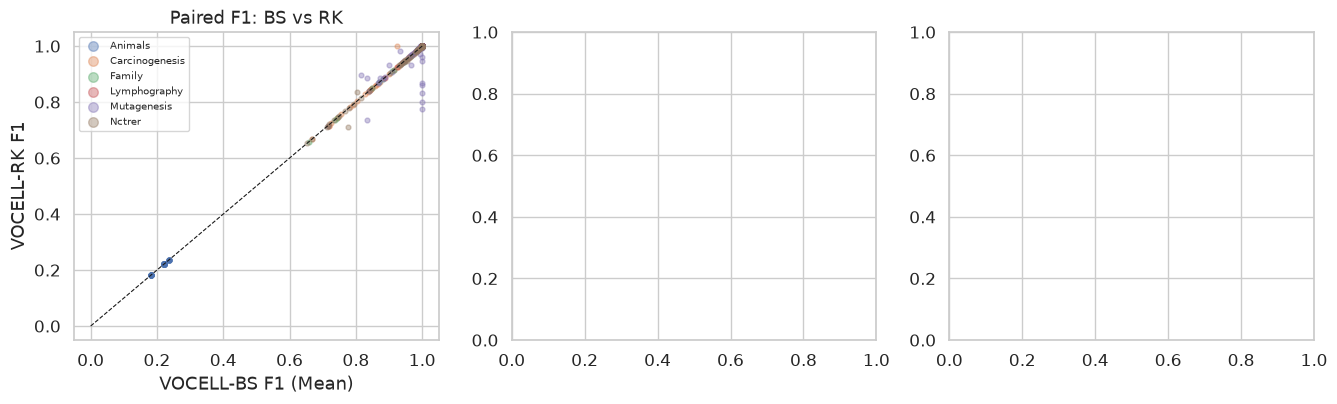

In [7]:
bs_mean = (all_df[(all_df["variant"]=="VOCELL-BS") & (all_df["model"]=="Mean")]
           [["dataset","lp_name","f1","runtime_s"]]
           .rename(columns={"f1":"f1_bs","runtime_s":"rt_bs"}))
rk_mean = (all_df[all_df["variant"]=="VOCELL-RK"]
           [["dataset","lp_name","f1","runtime_s"]]
           .rename(columns={"f1":"f1_rk","runtime_s":"rt_rk"}))

paired = bs_mean.merge(rk_mean, on=["dataset","lp_name"])
paired["delta_f1"] = paired["f1_rk"] - paired["f1_bs"]
paired["speedup"]  = paired["rt_bs"] / paired["rt_rk"].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter BS vs RK F1
ax = axes[0]
for ds in DATASETS:
    sub = paired[paired["dataset"] == ds]
    ax.scatter(sub["f1_bs"], sub["f1_rk"], alpha=0.4, s=12,
               label=DATASET_LABELS[ds])
ax.plot([0,1],[0,1], "k--", linewidth=0.8)
ax.set_xlabel("VOCELL-BS F1 (Mean)")
ax.set_ylabel("VOCELL-RK F1")
ax.set_title("Paired F1: BS vs RK")
ax.legend(fontsize=7, markerscale=2)

# Δ F1 distribution per dataset
ax = axes[1]
delta_data = [paired[paired["dataset"]==ds]["delta_f1"].values for ds in DATASETS]
bplot = ax.boxplot(delta_data, labels=[DATASET_LABELS[d] for d in DATASETS],
                   patch_artist=True, medianprops=dict(color="black", linewidth=2))
for patch, ds in zip(bplot["boxes"], DATASETS):
    patch.set_facecolor("#C44E52")
    patch.set_alpha(0.6)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_ylabel("Δ F1 (RK − BS)")
ax.set_title("F1 Delta: RK − BS per Dataset")
ax.tick_params(axis="x", rotation=30)

# Runtime comparison
ax = axes[2]
rt_comp = paired.groupby("dataset")[["rt_bs","rt_rk"]].mean().rename(
    columns={"rt_bs":"BS-Mean","rt_rk":"RK"})
rt_comp.index = [DATASET_LABELS[d] for d in rt_comp.index]
rt_comp.plot(kind="bar", ax=ax, color=["#4C72B0","#C44E52"],
             edgecolor="white", alpha=0.85)
ax.set_ylabel("Mean runtime (s)")
ax.set_title("Runtime: BS-Mean vs RK")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig("results_analysis_bs_vs_rk.png", dpi=150, bbox_inches="tight")
plt.show()

print("Paired comparison summary (per dataset):")
print(paired.groupby("dataset")[["f1_bs","f1_rk","delta_f1","rt_bs","rt_rk"]]
      .mean().round(4).to_string())


## 9 · Summary Statistics Table

In [12]:
summary = (all_df.groupby(["model","dataset"])
           .agg(
               n_lps       = ("lp_name", "count"),
               mean_f1     = ("f1",      "mean"),
               median_f1   = ("f1",      "median"),
               std_f1      = ("f1",      "std"),
               perfect_pct = ("perfect", lambda x: x.mean()*100),
               mean_rt_s   = ("runtime_s","mean"),
               mean_concepts = ("concepts_explored","mean"),
           )
           .reset_index())
summary["dataset_label"] = summary["dataset"].map(DATASET_LABELS)
summary = summary.sort_values(["dataset","model"])

# Also compute model-size for each model (same across datasets)
size_lookup = size_df.groupby("Model")["Parameters"].first().to_dict()
summary["params_K"] = summary["model"].map(size_lookup).fillna(0) / 1e3

display_cols = ["model","dataset_label","params_K","n_lps",
                "mean_f1","median_f1","std_f1","perfect_pct","mean_rt_s","mean_concepts"]
disp = summary[display_cols].rename(columns={
    "model":"Model","dataset_label":"Dataset","params_K":"Params(K)",
    "n_lps":"N","mean_f1":"Mean F1","median_f1":"Median F1",
    "std_f1":"Std F1","perfect_pct":"Perfect(%)","mean_rt_s":"RT(s)",
    "mean_concepts":"Concepts"
})
disp = disp.round({"Params(K)":1,"Mean F1":4,"Median F1":4,"Std F1":4,
                   "Perfect(%)":1,"RT(s)":2,"Concepts":1})
print(disp.to_string(index=False))


    Model        Dataset  Params(K)   N  Mean F1  Median F1  Std F1  Perfect(%)  RT(s)  Concepts
 DeepSets        Animals      462.3 300   0.8063      1.000  0.3391        75.3   5.89     103.1
     Mean        Animals      263.9 300   0.8063      1.000  0.3391        75.3   5.91     103.1
  Ranking        Animals       12.4 150   0.8063      1.000  0.3397        75.3   5.92     103.1
SetTransf        Animals      857.3 300   0.8063      1.000  0.3391        75.3   5.87     103.1
 DeepSets Carcinogenesis      462.3 151   0.9698      1.000  0.0672        60.9  63.02      22.1
     Mean Carcinogenesis      263.9 151   0.9698      1.000  0.0671        60.9  62.77      22.3
  Ranking Carcinogenesis       12.4 151   0.9688      1.000  0.0703        61.6  61.62      22.4
SetTransf Carcinogenesis      857.3   1   0.7200      0.720     NaN         0.0  86.85       5.0
 DeepSets         Family      462.3 157   0.9902      1.000  0.0453        93.0   5.37      84.9
     Mean         Family      

## 11 · LaTeX Results Table

In [13]:
import glob as _glob

# ── Table column order ────────────────────────────────────────────────────────
TABLE_DATASETS = ["family", "nctrer", "animals", "mutagenesis", "carcinogenesis", "lymphography"]

# ── Load other-learners results ───────────────────────────────────────────────
_ol_dfs = []
for _f in sorted(_glob.glob(str(ROOT / "results_other_learners" / "*.csv"))):
    _ol_dfs.append(pd.read_csv(_f))
ol = pd.concat(_ol_dfs, ignore_index=True)
ol = ol.rename(columns={"concepts_tested": "concepts_explored"})

# ── Aggregate: mean F1, mean concepts, mean runtime per learner × dataset ─────
def agg_stats(df, group_cols):
    return (df.groupby(group_cols)
              .agg(f1=("f1","mean"),
                   concepts=("concepts_explored","mean"),
                   rt=("runtime_s","mean"))
              .reset_index())

ol_agg  = agg_stats(ol,     ["dataset","learner"])
voc_agg = agg_stats(all_df, ["dataset","model"])

def lookup(agg_df, ds, name, key_col):
    row = agg_df[(agg_df["dataset"]==ds) & (agg_df[key_col]==name)]
    if row.empty:
        return None, None, None
    r = row.iloc[0]
    return r["f1"], r["concepts"], r["rt"]

def fmt(val, fmt_str):
    return "--" if val is None or (hasattr(val, "__float__") and pd.isna(float(val))) else fmt_str.format(val)

def row_cells(ds, name, key_col, agg_df):
    f1, concepts, rt = lookup(agg_df, ds, name, key_col)
    return (fmt(f1,       "{:.2f}"),
            fmt(concepts, "{:.0f}"),
            fmt(rt,       "{:.2f}"))

# ── Row definitions: (latex_label, lookup_name, key_col, agg_df) ─────────────
ROWS_BASELINES = [
    (r"\celoe{}",      "celoe",      "learner", ol_agg),
    (r"\drill{}",      "drill",      "learner", ol_agg),
    (r"\ocel{}",       "ocel",       "learner", ol_agg),
    (r"\alcsat{}",     "alcsat",     "learner", ol_agg),
    (r"\evolearner{}", "evolearner", "learner", ol_agg),
    (r"\celsystem{}",  "pruncel",    "learner", ol_agg),
    (r"\nero{}",       "nero",       "learner", ol_agg),
    (r"\spell{}",      "spell",      "learner", ol_agg),
    (r"\tdl{}",        "tdl",        "learner", ol_agg),
]
ROWS_VOCELL = [
    (r"\approachdr",           "drillv",    "learner",  ol_agg),
    (r"\approachrk",           "Ranking",   "model",    voc_agg),
    (r"\approachbs",           "Mean",      "model",    voc_agg),
    (r"{\approachbs}$^{DS}$",  "DeepSets",  "model",    voc_agg),
    (r"{\approachbs}$^{ST}$",  "SetTransf", "model",    voc_agg),
]

# ── Build LaTeX ───────────────────────────────────────────────────────────────
def build_table(rows):
    lines = []
    for label, name, key_col, agg_df in rows:
        parts = [label]
        for ds in TABLE_DATASETS:
            f1_s, c_s, rt_s = row_cells(ds, name, key_col, agg_df)
            parts += [f1_s, c_s, rt_s]
        lines.append("    " + " & ".join(parts) + r" \\")
    return "\n".join(lines)

latex = r"""\begin{table*}[tb]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{@{}lrrrrrrrrrrrrrrrrrr@{}}
\toprule
\multicolumn{1}{c}{\textbf{Approach}}
& \multicolumn{3}{c}{\textbf{Family}}
& \multicolumn{3}{c}{\textbf{Nctrer}}
& \multicolumn{3}{c}{\textbf{Animals}}
& \multicolumn{3}{c}{\textbf{Mutagenesis}}
& \multicolumn{3}{c}{\textbf{Carcinogenesis}}
& \multicolumn{3}{c}{\textbf{Lymphography}}
\\
\cmidrule(r){2-4}\cmidrule(lr){5-7}\cmidrule(l){8-10}
\cmidrule(l){11-13}\cmidrule(l){14-16}\cmidrule(l){17-19}
&
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT}
\\
\midrule
""" + build_table(ROWS_BASELINES) + r"""
\midrule
""" + build_table(ROWS_VOCELL) + r"""
\bottomrule
\end{tabular}
}
\caption{Average F1 score, number of generated concepts ($\ell(\mathcal{C})$), and runtime (RT, in seconds).
Bold values indicate the best results, and underlined values are the second best.
-- indicates that no results were returned.
\approachbs, {\approachbs}$^{DS}$ and {\approachbs}$^{ST}$ are \approach regression variants
using mean, deep-sets and set-transformer aggregation respectively.}
\label{tab:results-exp1}
\vspace{-3mm}
\end{table*}"""

print(latex)


\begin{table*}[tb]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{@{}lrrrrrrrrrrrrrrrrrr@{}}
\toprule
\multicolumn{1}{c}{\textbf{Approach}}
& \multicolumn{3}{c}{\textbf{Family}}
& \multicolumn{3}{c}{\textbf{Nctrer}}
& \multicolumn{3}{c}{\textbf{Animals}}
& \multicolumn{3}{c}{\textbf{Mutagenesis}}
& \multicolumn{3}{c}{\textbf{Carcinogenesis}}
& \multicolumn{3}{c}{\textbf{Lymphography}}
\\
\cmidrule(r){2-4}\cmidrule(lr){5-7}\cmidrule(l){8-10}
\cmidrule(l){11-13}\cmidrule(l){14-16}\cmidrule(l){17-19}
&
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \multicolumn{1}{c}{$\ell(\mathcal{C})$} & \multicolumn{1}{c}{RT} &
\multicolumn{1}{c}{F1} & \mu

## 12 · Wilcoxon Signed-Rank Tests — VOCELL vs Baselines

For each VOCELL variant × each baseline method, we run a two-sided Wilcoxon signed-rank test on three metrics (in order):
1. **Concepts explored** — search efficiency
2. **F1** — quality
3. **Runtime** — speed

Only LPs where **both** methods returned a result are included. p-values are Bonferroni-corrected across all VOCELL×baseline×metric combinations.


In [18]:
from scipy.stats import wilcoxon
import itertools, warnings

warnings.filterwarnings("ignore", category=UserWarning)

# ── Build unified long table ──────────────────────────────────────────────────
voc_long = all_df[["dataset","lp_name","model","f1","runtime_s","concepts_explored"]].copy()
voc_long = voc_long.rename(columns={"model":"method"})
VOC_DISPLAY = {
    "Mean":     "VOCELL-BS",
    "DeepSets": "VOCELL-BS^DS",
    "SetTransf":"VOCELL-BS^ST",
    "Ranking":  "VOCELL-RK",
}
voc_long["method"] = voc_long["method"].map(VOC_DISPLAY)

ol_long = ol[["dataset","lp_name","learner","f1","runtime_s","concepts_explored"]].copy()
ol_long = ol_long.rename(columns={"learner":"method"})
OL_DISPLAY = {
    "celoe":      "CELOE",
    "ocel":       "OCEL",
    "evolearner": "EvoLearner",
    "alcsat":     "ALCSAT",
    "spell":      "SPELL",
    "nero":       "NERO",
    "drill":      "Drill",
    "drillv":     "VOCELL-DR",
    "pruncel":    "PruneCEL",
    "tdl":        "TDL",
}
ol_long["method"] = ol_long["method"].map(OL_DISPLAY)

all_long = pd.concat([voc_long, ol_long], ignore_index=True)
all_long = all_long.dropna(subset=["method"])

# Deduplicate: mean per (dataset, lp_name, method)
all_long = (all_long
            .groupby(["dataset","lp_name","method"], as_index=False)
            [["f1","runtime_s","concepts_explored"]]
            .mean())

VOCELL_METHODS   = ["VOCELL-BS", "VOCELL-BS^DS", "VOCELL-BS^ST", "VOCELL-RK", "VOCELL-DR"]
BASELINE_METHODS = ["CELOE", "OCEL", "EvoLearner", "ALCSAT", "SPELL", "NERO", "Drill", "PruneCEL", "TDL"]
METRICS = ["concepts_explored", "f1", "runtime_s"]
METRIC_LABELS = {
    "concepts_explored": "Concepts Explored",
    "f1":                "F1",
    "runtime_s":         "Runtime (s)",
}

# Bonferroni: number of (vocell × baseline × metric) combinations
n_tests = len(VOCELL_METHODS) * len(BASELINE_METHODS) * len(METRICS)

records = []
for voc in VOCELL_METHODS:
    dv = all_long[all_long["method"] == voc].set_index(["dataset","lp_name"])
    for base in BASELINE_METHODS:
        db = all_long[all_long["method"] == base].set_index(["dataset","lp_name"])
        common = dv.index.intersection(db.index)
        if len(common) < 5:
            continue
        for metric in METRICS:
            x = dv.loc[common, metric].values.astype(float)
            y = db.loc[common, metric].values.astype(float)
            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]
            if len(x) < 5:
                continue
            try:
                stat, pval = wilcoxon(x, y, zero_method="wilcox")
            except ValueError:
                stat, pval = 0.0, 1.0
            pval_bonf = min(pval * n_tests, 1.0)
            records.append({
                "VOCELL":    voc,
                "Baseline":  base,
                "Metric":    METRIC_LABELS[metric],
                "N pairs":   int(mask.sum()),
                "Mean VOCELL": round(float(np.nanmean(x)), 4),
                "Mean Base":   round(float(np.nanmean(y)), 4),
                "p-value":   round(pval, 6),
                "p-bonf":    round(pval_bonf, 6),
                "Sig":       "***" if pval_bonf < 0.001
                             else "**"  if pval_bonf < 0.01
                             else "*"   if pval_bonf < 0.05
                             else "ns",
            })

wilcox_df = pd.DataFrame(records)
print(f"Bonferroni n_tests = {n_tests}  |  Result rows: {len(wilcox_df)}")
print(f"\nSignificant results (p-bonf < 0.05):")
sig = wilcox_df[wilcox_df["Sig"] != "ns"].sort_values(["Metric","p-bonf"])
print(sig.to_string(index=False))


Bonferroni n_tests = 135  |  Result rows: 120

Significant results (p-bonf < 0.05):
      VOCELL   Baseline            Metric  N pairs  Mean VOCELL  Mean Base  p-value   p-bonf Sig
   VOCELL-BS      CELOE Concepts Explored      899      49.5417  1514.3560 0.000000 0.000000 ***
   VOCELL-BS       OCEL Concepts Explored      899      49.5417  1027.9544 0.000000 0.000000 ***
   VOCELL-BS EvoLearner Concepts Explored      749      38.8104   803.1121 0.000000 0.000000 ***
   VOCELL-BS      Drill Concepts Explored      899      49.5417  1705.3904 0.000000 0.000000 ***
   VOCELL-BS   PruneCEL Concepts Explored      300      88.9867 22562.4867 0.000000 0.000000 ***
   VOCELL-BS        TDL Concepts Explored      302      41.4702     0.0000 0.000000 0.000000 ***
VOCELL-BS^DS      CELOE Concepts Explored      899      51.1001  1514.3560 0.000000 0.000000 ***
VOCELL-BS^DS       OCEL Concepts Explored      899      51.1001  1027.9544 0.000000 0.000000 ***
VOCELL-BS^DS EvoLearner Concepts Explored  

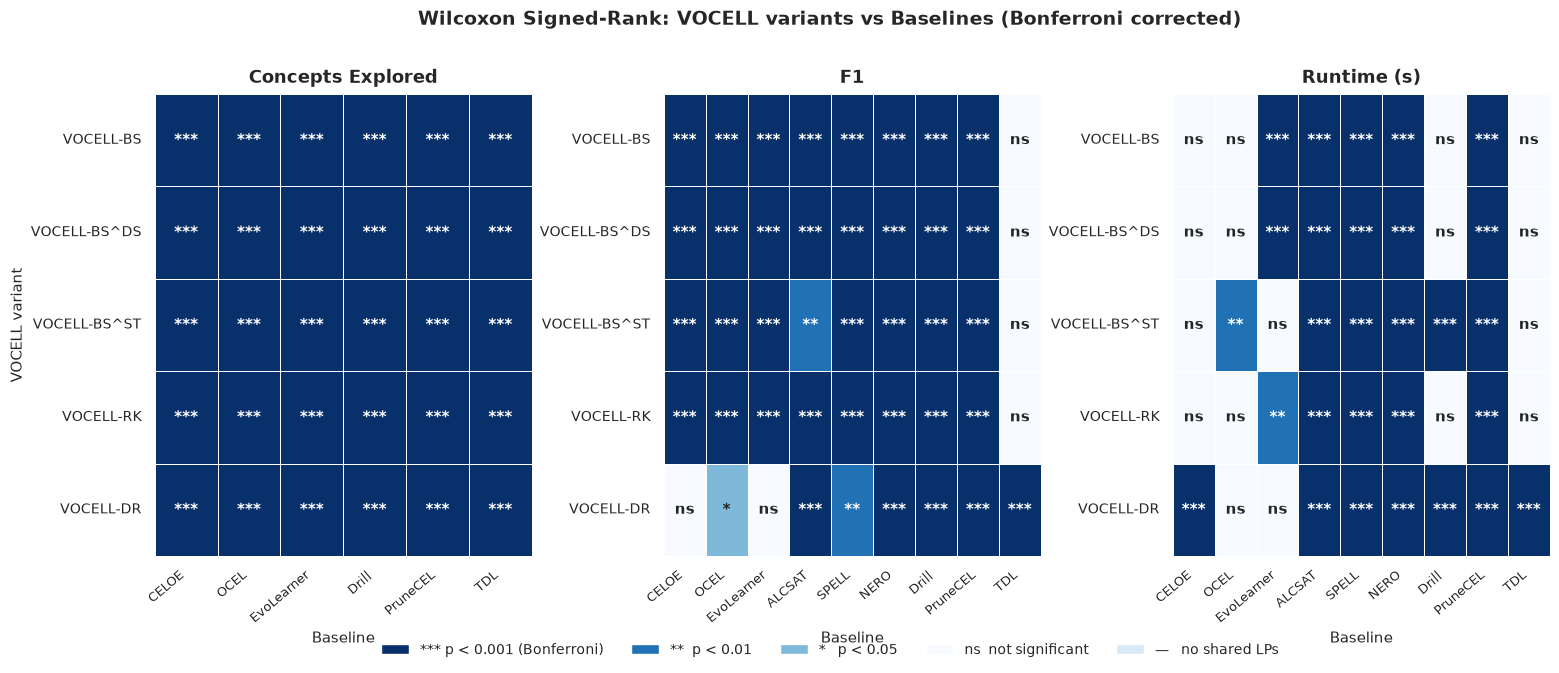

In [19]:
# ── Heatmap grid: VOCELL methods (rows) × Baselines (cols), one panel per metric
SIG_VAL = {"***": 0.0, "**": 0.25, "*": 0.55, "ns": 1.0, "": 0.85}
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, len(VOCELL_METHODS) * 0.7 + 2.5),
                         gridspec_kw={"wspace": 0.35})

for ax, metric in zip(axes, METRICS):
    label = METRIC_LABELS[metric]
    sub = wilcox_df[wilcox_df["Metric"] == label]

    mat_sig   = pd.DataFrame("", index=VOCELL_METHODS, columns=BASELINE_METHODS)
    mat_color = pd.DataFrame(0.85, index=VOCELL_METHODS, columns=BASELINE_METHODS)

    for _, row in sub.iterrows():
        v, b, sig = row["VOCELL"], row["Baseline"], row["Sig"]
        if v in VOCELL_METHODS and b in BASELINE_METHODS:
            mat_sig.loc[v, b]   = sig
            mat_color.loc[v, b] = SIG_VAL[sig]

    # Filter to baselines that appear in at least one result
    active_bases = [b for b in BASELINE_METHODS if mat_sig[b].str.strip().ne("").any()]
    mat_sig   = mat_sig[active_bases]
    mat_color = mat_color[active_bases]

    sns.heatmap(mat_color.astype(float), ax=ax,
                cmap="Blues_r", vmin=0, vmax=1,
                linewidths=0.5, linecolor="white",
                cbar=False,
                annot=mat_sig.values, fmt="",
                annot_kws={"size": 11, "weight": "bold"})
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Baseline", fontsize=11)
    ax.set_ylabel("VOCELL variant" if ax is axes[0] else "", fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

legend_els = [
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL["***"]), label="*** p < 0.001 (Bonferroni)"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL["**"]),  label="**  p < 0.01"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL["*"]),   label="*   p < 0.05"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL["ns"]),  label="ns  not significant"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL[""]),    label="—   no shared LPs"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=5,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Wilcoxon Signed-Rank: VOCELL variants vs Baselines (Bonferroni corrected)",
             fontsize=14, fontweight="bold", y=1.02)
# plt.savefig("results_analysis_wilcoxon_heatmap.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("results_analysis_wilcoxon_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:

# ── LaTeX table: VOCELL vs Baselines Wilcoxon results ────────────────────────
METRIC_SHORT = {
    "Concepts Explored": "Concepts",
    "F1":                "F1",
    "Runtime (s)":       "Runtime",
}

def winner_label(row):
    metric_key = {v: k for k, v in METRIC_LABELS.items()}[row["Metric"]]
    voc_val  = row["Mean VOCELL"]
    base_val = row["Mean Base"]
    if row["Sig"] == "ns":
        return r"\textemdash"
    if metric_key == "f1":
        return row["VOCELL"] if voc_val >= base_val else row["Baseline"]
    else:  # lower is better for concepts / runtime
        return row["VOCELL"] if voc_val <= base_val else row["Baseline"]

def escape_tex(s):
    return s.replace("^", r"\^{}").replace("_", r"\_")

lines = []
lines.append(r"\begin{table*}[tb]")
lines.append(r"\centering")
lines.append(r"\resizebox{\textwidth}{!}{%")
lines.append(r"\begin{tabular}{@{}ll" + "r@{\hspace{4pt}}l" * len(METRICS) + r"@{}}")
lines.append(r"\toprule")

# Header
header_cols = [r"\textbf{VOCELL}", r"\textbf{Baseline}"]
for metric in METRICS:
    mshort = METRIC_SHORT[METRIC_LABELS[metric]]
    header_cols.append(r"\multicolumn{2}{c}{\textbf{" + mshort + r"}}")
lines.append(" & ".join(header_cols) + r" \\")

# Sub-header: p-bonf | winner
sub_cols = ["", ""]
for _ in METRICS:
    sub_cols += [r"\textit{p-bonf}", r"\textit{winner}"]
lines.append(r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}")
lines.append(" & ".join(sub_cols) + r" \\")
lines.append(r"\midrule")

prev_voc = None
for voc in VOCELL_METHODS:
    sub = wilcox_df[wilcox_df["VOCELL"] == voc].copy()
    if sub.empty:
        continue
    # Group by baseline, iterate metrics as columns
    baselines_here = [b for b in BASELINE_METHODS if b in sub["Baseline"].values]
    first_row = True
    for base in baselines_here:
        row_parts = []
        # VOCELL label only on first baseline row
        if first_row:
            voc_cell = r"\textbf{" + escape_tex(voc) + r"}"
            first_row = False
        else:
            voc_cell = ""
        row_parts.append(voc_cell)
        row_parts.append(escape_tex(base))
        for metric in METRICS:
            mlab = METRIC_LABELS[metric]
            match = sub[(sub["Baseline"] == base) & (sub["Metric"] == mlab)]
            if match.empty:
                row_parts += [r"\textemdash", r"\textemdash"]
            else:
                r = match.iloc[0]
                sig_str = r["Sig"]
                pval_str = f"{r['p-bonf']:.4f}"
                if sig_str != "ns":
                    pval_str = r"\mathbf{" + pval_str + r"}^{" + sig_str + r"}"
                    pval_str = f"${pval_str}$"
                win = winner_label(r)
                win_str = escape_tex(win)
                if win.startswith("VOCELL"):
                    win_str = r"\textbf{" + win_str + r"}"
                row_parts += [pval_str, win_str]
        lines.append("    " + " & ".join(row_parts) + r" \\")
    lines.append(r"\midrule")

# Remove last \midrule before \bottomrule
lines[-1] = r"\bottomrule"
lines.append(r"\end{tabular}")
lines.append(r"}% end resizebox")
lines.append(r"\caption{Wilcoxon signed-rank test results (Bonferroni corrected, $n=" + str(n_tests) + r"$ tests).")
lines.append(r"Bold p-values are significant ($p_\text{bonf} < 0.05$). The winner column shows which method")
lines.append(r"performs better (higher F1; fewer concepts/runtime). \textemdash{} = not significant or no shared LPs.}")
lines.append(r"\label{tab:wilcoxon}")
lines.append(r"\end{table*}")

latex_wilcox = "\n".join(lines)
print(latex_wilcox)


\begin{table*}[tb]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{@{}llr@{\hspace{4pt}}lr@{\hspace{4pt}}lr@{\hspace{4pt}}l@{}}
\toprule
\textbf{VOCELL} & \textbf{Baseline} & \multicolumn{2}{c}{\textbf{Concepts}} & \multicolumn{2}{c}{\textbf{F1}} & \multicolumn{2}{c}{\textbf{Runtime}} \\
\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}
 &  & \textit{p-bonf} & \textit{winner} & \textit{p-bonf} & \textit{winner} & \textit{p-bonf} & \textit{winner} \\
\midrule
    \textbf{VOCELL-BS} & CELOE & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & 0.0531 & \textemdash \\
     & OCEL & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & 1.0000 & \textemdash \\
     & EvoLearner & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & $\mathbf{0.0002}^{***}$ & EvoLearner \\
     & ALCSAT & \textemdash & \textemdash & $\mathbf{0.0002}^{***}$ & \textbf{VOCELL-BS}

## 13 · Wilcoxon Tests — VOCELL Variants vs Each Other

In [22]:

# ── Pairwise Wilcoxon between VOCELL variants only ───────────────────────────
from itertools import combinations

VOCELL_PAIRS = list(combinations(VOCELL_METHODS, 2))
n_tests_voc  = len(VOCELL_PAIRS) * len(METRICS)

records_voc = []
for (v1, v2) in VOCELL_PAIRS:
    d1 = all_long[all_long["method"] == v1].set_index(["dataset","lp_name"])
    d2 = all_long[all_long["method"] == v2].set_index(["dataset","lp_name"])
    common = d1.index.intersection(d2.index)
    if len(common) < 5:
        continue
    for metric in METRICS:
        x = d1.loc[common, metric].values.astype(float)
        y = d2.loc[common, metric].values.astype(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        if len(x) < 5:
            continue
        try:
            stat, pval = wilcoxon(x, y, zero_method="wilcox")
        except ValueError:
            stat, pval = 0.0, 1.0
        pval_bonf = min(pval * n_tests_voc, 1.0)
        records_voc.append({
            "V1":       v1,
            "V2":       v2,
            "Metric":   METRIC_LABELS[metric],
            "N pairs":  int(mask.sum()),
            "Mean V1":  round(float(np.nanmean(x)), 4),
            "Mean V2":  round(float(np.nanmean(y)), 4),
            "p-value":  round(pval, 6),
            "p-bonf":   round(pval_bonf, 6),
            "Sig":      "***" if pval_bonf < 0.001
                        else "**"  if pval_bonf < 0.01
                        else "*"   if pval_bonf < 0.05
                        else "ns",
        })

voc_voc_df = pd.DataFrame(records_voc)
print(f"Bonferroni n_tests = {n_tests_voc}  |  Result rows: {len(voc_voc_df)}")
print(f"\nSignificant results (p-bonf < 0.05):")
sig_voc = voc_voc_df[voc_voc_df["Sig"] != "ns"].sort_values(["Metric","p-bonf"])
print(sig_voc.to_string(index=False))


Bonferroni n_tests = 30  |  Result rows: 30

Significant results (p-bonf < 0.05):
          V1           V2            Metric  N pairs  Mean V1  Mean V2  p-value   p-bonf Sig
   VOCELL-BS    VOCELL-DR Concepts Explored      899  49.5417 797.4227 0.000000 0.000000 ***
VOCELL-BS^DS    VOCELL-DR Concepts Explored      899  51.1001 797.4227 0.000000 0.000000 ***
VOCELL-BS^ST    VOCELL-DR Concepts Explored      751  58.3768 951.4434 0.000000 0.000000 ***
   VOCELL-RK    VOCELL-DR Concepts Explored      899  47.6674 797.4227 0.000000 0.000000 ***
   VOCELL-BS    VOCELL-RK Concepts Explored      908  49.2919  47.4361 0.000008 0.000225 ***
VOCELL-BS^ST    VOCELL-RK Concepts Explored      759  59.8709  52.3030 0.000050 0.001508  **
   VOCELL-BS    VOCELL-DR                F1      899   0.9523   0.8642 0.000000 0.000000 ***
VOCELL-BS^DS    VOCELL-DR                F1      899   0.9513   0.8642 0.000000 0.000000 ***
VOCELL-BS^ST    VOCELL-DR                F1      751   0.9482   0.8662 0.000000 0

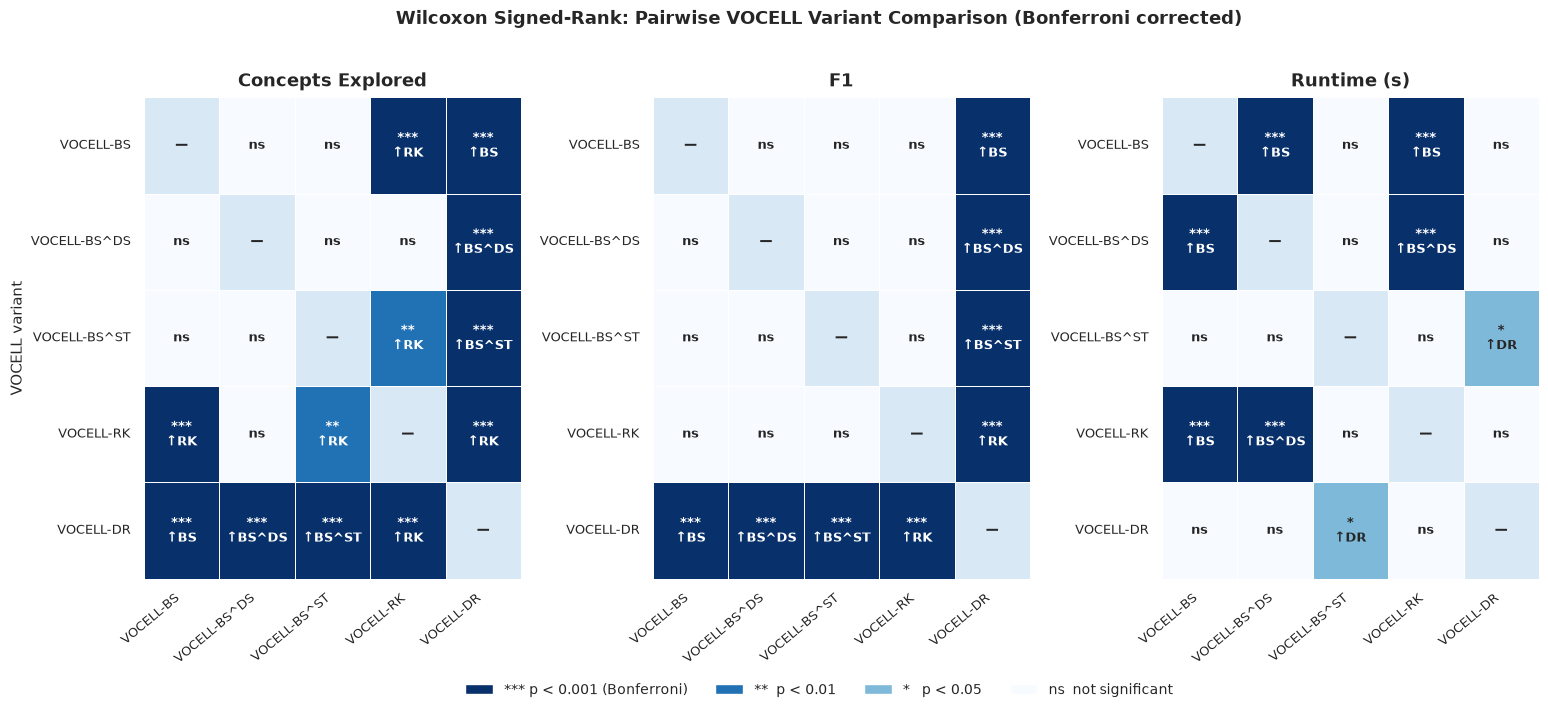

In [23]:

# ── Heatmap: one panel per metric, symmetric pair matrix ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, len(VOCELL_METHODS) * 0.85 + 2),
                         gridspec_kw={"wspace": 0.35})

SIG_VAL_VOC = {"***": 0.0, "**": 0.25, "*": 0.55, "ns": 1.0, "": 0.85}

for ax, metric in zip(axes, METRICS):
    label = METRIC_LABELS[metric]
    sub   = voc_voc_df[voc_voc_df["Metric"] == label]

    mat_sig   = pd.DataFrame("", index=VOCELL_METHODS, columns=VOCELL_METHODS)
    mat_color = pd.DataFrame(0.85, index=VOCELL_METHODS, columns=VOCELL_METHODS)

    # Fill diagonal as "—" (self-comparison)
    for v in VOCELL_METHODS:
        mat_sig.loc[v, v]   = "—"
        mat_color.loc[v, v] = 0.85

    for _, row in sub.iterrows():
        v1, v2, sig = row["V1"], row["V2"], row["Sig"]
        # Direction annotation: which variant is better?
        if sig != "ns":
            if label == "F1":
                better = v1 if row["Mean V1"] >= row["Mean V2"] else v2
            else:  # lower is better
                better = v1 if row["Mean V1"] <= row["Mean V2"] else v2
            ann = f"{sig}\n↑{better.split('-')[-1]}"
        else:
            ann = sig
        mat_sig.loc[v1, v2]   = ann
        mat_sig.loc[v2, v1]   = ann
        mat_color.loc[v1, v2] = SIG_VAL_VOC[sig]
        mat_color.loc[v2, v1] = SIG_VAL_VOC[sig]

    sns.heatmap(mat_color.astype(float), ax=ax,
                cmap="Blues_r", vmin=0, vmax=1,
                linewidths=0.5, linecolor="white",
                cbar=False,
                annot=mat_sig.values, fmt="",
                annot_kws={"size": 9, "weight": "bold"})
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("" if ax is not axes[0] else "VOCELL variant", fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

legend_els = [
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL_VOC["***"]), label="*** p < 0.001 (Bonferroni)"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL_VOC["**"]),  label="**  p < 0.01"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL_VOC["*"]),   label="*   p < 0.05"),
    Patch(facecolor=plt.cm.Blues_r(SIG_VAL_VOC["ns"]),  label="ns  not significant"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=4,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.suptitle("Wilcoxon Signed-Rank: Pairwise VOCELL Variant Comparison (Bonferroni corrected)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("results_analysis_wilcoxon_vocell_pairs.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [24]:

# ── LaTeX table: pairwise VOCELL variant Wilcoxon ────────────────────────────
lines_vv = []
lines_vv.append(r"\begin{table}[tb]")
lines_vv.append(r"\centering")
lines_vv.append(r"\resizebox{\columnwidth}{!}{%")
lines_vv.append(r"\begin{tabular}{@{}ll" + "r@{\hspace{4pt}}l" * len(METRICS) + r"@{}}")
lines_vv.append(r"\toprule")

header = [r"\textbf{V1}", r"\textbf{V2}"]
for metric in METRICS:
    header.append(r"\multicolumn{2}{c}{\textbf{" + METRIC_SHORT[METRIC_LABELS[metric]] + r"}}")
lines_vv.append(" & ".join(header) + r" \\")

sub_h = ["", ""]
for _ in METRICS:
    sub_h += [r"\textit{p-bonf}", r"\textit{better}"]
lines_vv.append(r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}")
lines_vv.append(" & ".join(sub_h) + r" \\")
lines_vv.append(r"\midrule")

for (v1, v2) in VOCELL_PAIRS:
    sub = voc_voc_df[(voc_voc_df["V1"]==v1) & (voc_voc_df["V2"]==v2)]
    if sub.empty:
        continue
    row_parts = [escape_tex(v1), escape_tex(v2)]
    for metric in METRICS:
        mlab  = METRIC_LABELS[metric]
        match = sub[sub["Metric"] == mlab]
        if match.empty:
            row_parts += [r"\textemdash", r"\textemdash"]
            continue
        r = match.iloc[0]
        sig_str  = r["Sig"]
        pval_str = f"{r['p-bonf']:.4f}"
        if sig_str != "ns":
            pval_str = f"$\\mathbf{{{pval_str}}}^{{{sig_str}}}$"
            # determine better variant
            if mlab == "F1":
                better = v1 if r["Mean V1"] >= r["Mean V2"] else v2
            else:
                better = v1 if r["Mean V1"] <= r["Mean V2"] else v2
            better_str = r"\textbf{" + escape_tex(better) + r"}"
        else:
            better_str = r"\textemdash"
        row_parts += [pval_str, better_str]
    lines_vv.append("    " + " & ".join(row_parts) + r" \\")

lines_vv.append(r"\bottomrule")
lines_vv.append(r"\end{tabular}")
lines_vv.append(r"}% end resizebox")
lines_vv.append(r"\caption{Pairwise Wilcoxon signed-rank tests between \approach variants")
lines_vv.append(r"(Bonferroni corrected, $n=" + str(n_tests_voc) + r"$ tests).")
lines_vv.append(r"Bold p-values indicate significance ($p_\text{bonf}<0.05$);")
lines_vv.append(r"the \emph{better} column names the winning variant.")
lines_vv.append(r"\textemdash{} = not significant or insufficient paired LPs.}")
lines_vv.append(r"\label{tab:wilcoxon-vocell}")
lines_vv.append(r"\end{table}")

print("\n".join(lines_vv))


\begin{table}[tb]
\centering
\resizebox{\columnwidth}{!}{%
\begin{tabular}{@{}llr@{\hspace{4pt}}lr@{\hspace{4pt}}lr@{\hspace{4pt}}l@{}}
\toprule
\textbf{V1} & \textbf{V2} & \multicolumn{2}{c}{\textbf{Concepts}} & \multicolumn{2}{c}{\textbf{F1}} & \multicolumn{2}{c}{\textbf{Runtime}} \\
\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}
 &  & \textit{p-bonf} & \textit{better} & \textit{p-bonf} & \textit{better} & \textit{p-bonf} & \textit{better} \\
\midrule
    VOCELL-BS & VOCELL-BS\^{}DS & 1.0000 & \textemdash & 1.0000 & \textemdash & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} \\
    VOCELL-BS & VOCELL-BS\^{}ST & 1.0000 & \textemdash & 1.0000 & \textemdash & 1.0000 & \textemdash \\
    VOCELL-BS & VOCELL-RK & $\mathbf{0.0002}^{***}$ & \textbf{VOCELL-RK} & 1.0000 & \textemdash & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} \\
    VOCELL-BS & VOCELL-DR & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & $\mathbf{0.0000}^{***}$ & \textbf{VOCELL-BS} & 0.3532 & \textemdash \\
    VOCELL

## 14 · Qualitative Analysis — Concepts VOCELL Solves / Misses

In [27]:

# ── Load best predictions per LP for each method ─────────────────────────────
import glob as _glob2, re as _re

AGG_MAP = {
    "V-Net [mean / bootstrap]":         "VOCELL-BS",
    "V-Net [deepsets / bootstrap]":     "VOCELL-BS^DS",
    "V-Net [settransformer / bootstrap]":"VOCELL-BS^ST",
}
# For ranking results (same agg labels reused in ranking CSV if present, otherwise a single file)
LEARNER_MAP = {
    "celoe":"CELOE","ocel":"OCEL","evolearner":"EvoLearner",
    "alcsat":"ALCSAT","spell":"SPELL","nero":"NERO",
    "drill":"Drill","drillv":"VOCELL-DR","pruncel":"PruneCEL","tdl":"TDL",
}

rows = []
DATASETS =  ["carcinogenesis", "family",
            "lymphography", "mutagenesis", "nctrer"]
for ds in DATASETS:
    # VOCELL-BS variants
    f = ROOT / "results" / f"{ds}_results.csv"
    if f.exists():
        df = pd.read_csv(f)
        for _, r in df.iterrows():
            method = AGG_MAP.get(r["agg_method"], r["agg_method"])
            rows.append(dict(dataset=ds, lp=r["lp_name"], method=method,
                             f1=r["f1"], concept=r.get("best_concept","")))
    # VOCELL-RK
    f = ROOT / "results_ranking" / f"{ds}_results.csv"
    if f.exists():
        df = pd.read_csv(f)
        # keep only ranking rows (agg_method distinguishes or use all)
        for _, r in df.iterrows():
            # If the ranking CSV also stores BS variants, skip duplicates
            method = "VOCELL-RK"
            rows.append(dict(dataset=ds, lp=r["lp_name"], method=method,
                             f1=r["f1"], concept=r.get("best_concept","")))
    # Other learners
    for _f in sorted(_glob2.glob(str(ROOT / "results_other_learners" / f"*{ds}*.csv"))):
        df = pd.read_csv(_f)
        df = df.rename(columns={"concepts_tested":"concepts_explored"})
        for _, r in df.iterrows():
            method = LEARNER_MAP.get(r["learner"], r["learner"])
            rows.append(dict(dataset=ds, lp=r["lp_name"], method=method,
                             f1=r["f1"], concept=r.get("best_concept","")))

all_res = pd.DataFrame(rows)
print(f"Total records: {len(all_res)}")
print("Methods present:", sorted(all_res["method"].unique()))


Total records: 9330
Methods present: ['ALCSAT', 'CELOE', 'Drill', 'EvoLearner', 'NERO', 'OCEL', 'PruneCEL', 'SPELL', 'TDL', 'VOCELL-BS', 'VOCELL-BS^DS', 'VOCELL-BS^ST', 'VOCELL-DR', 'VOCELL-RK']


In [ ]:

# ── Qualitative analysis ──────────────────────────────────────────────────────
VOCELL_SET = {"VOCELL-BS","VOCELL-BS^DS","VOCELL-BS^ST","VOCELL-RK"}
BASELINE_SET = set(LEARNER_MAP.values()) - {"VOCELL-DR"}

F1_SUCCESS = .95      # threshold to count as "solved"
F1_FAIL    = 0.80      # threshold to count as "failed"

# Per-LP: max F1 over all VOCELL variants, max F1 over all baselines
pivot_voc  = (all_res[all_res["method"].isin(VOCELL_SET)]
              .groupby(["dataset","lp"])["f1"].max().rename("f1_voc"))
pivot_base = (all_res[all_res["method"].isin(BASELINE_SET)]
              .groupby(["dataset","lp"])["f1"].max().rename("f1_base"))
lp_summary = pd.concat([pivot_voc, pivot_base], axis=1).dropna()

# -- Case A: VOCELL perfect (1.0) & best baseline fails (<= F1_FAIL) ----------
voc_only = lp_summary[(lp_summary["f1_voc"] >= F1_SUCCESS) &
                       (lp_summary["f1_base"] <= F1_FAIL)].reset_index()

# -- Case B: VOCELL fails (<= F1_FAIL) & best baseline succeeds (>= F1_SUCCESS)
base_only = lp_summary[(lp_summary["f1_voc"] <= F1_FAIL) &
                        (lp_summary["f1_base"] >= F1_SUCCESS)].reset_index()

# Enrich with the actual concept string found by best VOCELL variant
def best_voc_concept(ds, lp):
    sub = all_res[(all_res["dataset"]==ds) & (all_res["lp"]==lp) &
                  all_res["method"].isin(VOCELL_SET)]
    if sub.empty: return ""
    return sub.loc[sub["f1"].idxmax(), "concept"]

def best_base_concept(ds, lp):
    sub = all_res[(all_res["dataset"]==ds) & (all_res["lp"]==lp) &
                  all_res["method"].isin(BASELINE_SET)]
    if sub.empty: return ""
    return sub.loc[sub["f1"].idxmax(), "concept"]

voc_only["voc_concept"]  = [best_voc_concept(r.dataset, r.lp)  for r in voc_only.itertuples()]
voc_only["base_concept"] = [best_base_concept(r.dataset, r.lp) for r in voc_only.itertuples()]
base_only["voc_concept"] = [best_voc_concept(r.dataset, r.lp)  for r in base_only.itertuples()]
base_only["base_concept"]= [best_base_concept(r.dataset, r.lp) for r in base_only.itertuples()]

# ── Concept complexity heuristics ────────────────────────────────────────────
def concept_complexity(c):
    """Return a rough structural label."""
    c = str(c)
    if "∀" in c:        return "Universal"
    if "⊔" in c:        return "Union"
    if "¬" in c:        return "Negation"
    if "∃" in c and "⊓" in c: return "Exist+Conj"
    if "∃" in c:        return "Existential"
    if "⊓" in c:        return "Conjunction"
    return "Atomic/Simple"

voc_only["complexity"]  = voc_only["voc_concept"].apply(concept_complexity)
base_only["complexity"] = base_only["base_concept"].apply(concept_complexity)

# ── Print summary ─────────────────────────────────────────────────────────────
pd.set_option("display.max_colwidth", 70)

print(f"=== Case A: VOCELL F1≥{F1_SUCCESS}, best baseline ≤{F1_FAIL} ({len(voc_only)} LPs) ===")
print(voc_only[["dataset","lp","f1_base","complexity","voc_concept"]].to_string(index=False))

print(f"\n=== Case B: VOCELL ≤{F1_FAIL}, best baseline F1≥{F1_SUCCESS} ({len(base_only)} LPs) ===")
print(base_only[["dataset","lp","f1_voc","f1_base","voc_concept","base_concept"]].to_string(index=False))

# ── Count how many Case B LPs involve universal restrictions ─────────────────
n_universal = (base_only["base_concept"].str.contains("∀", na=False)).sum()
print(f"\n  → {n_universal} of {len(base_only)} Case B LPs have a universal restriction (∀) in the baseline concept.")

print("""
Why VOCELL struggles with universal concepts (∀r.C):
  VOCELL's V-Net is trained on existential search trees generated by a
  LengthBasedRefinement operator that prioritises ∃-restrictions; universal
  fillers (∀r.C) are therefore rare or absent in the training signal, so the
  value network never learns to score them highly and the beam search prunes
  them away before they can be fully expanded.
""")


=== Case A: VOCELL F1≥0.95, best baseline ≤0.8 (3 LPs) ===
       dataset                                                lp  f1_base complexity                                  voc_concept
carcinogenesis Carbon-191 ⊔ Nitrogen-32 ⊔ (∃ isMutagenic.{True})   0.7622      Union        Nitrogen-32 ⊔ (Compound ⊔ Carbon-191)
carcinogenesis Carbon-27 ⊔ Oxygen-49 ⊔ (∃ drosophila_rt.{False})   0.7380      Union Oxygen-49 ⊔ (Carbon-27 ⊔ (∃ hasStructure.⊤))
carcinogenesis              Nitrogen-32 ⊔ (∃ salmonella.{False})   0.7311      Union                       Nitrogen-32 ⊔ Compound

=== Case B: VOCELL ≤0.8, best baseline F1≥0.95 (5 LPs) ===
       dataset                 lp  f1_voc  f1_base                                                      voc_concept
carcinogenesis           NOTKNOWN  0.7200      1.0                                             ∃ hasAtom.Hydrogen-3
        family  ∀ married.Brother  0.6577      1.0                 (¬(Parent ⊓ Child)) ⊓ ((∃ hasParent.⊤) ⊔ Female)
        famil

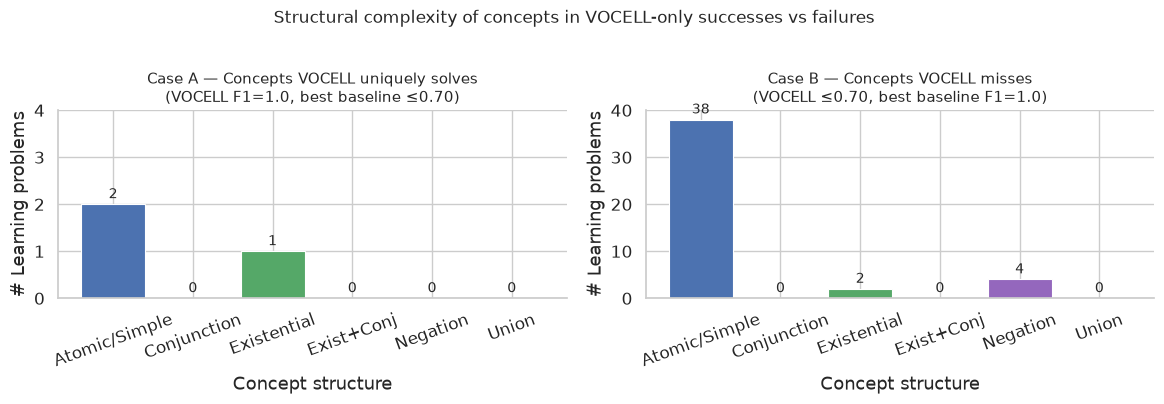

Avg loss: 12.36499

Goal Concept:	 Bond-1	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0]
Avg loss: 2.26567

Goal Concept:	 SingleBondEitherUpOrDownStereochemistry	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0, 0]
Avg loss: 0.31494

Goal Concept:	 Nitrogen-31	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0, 0]
Avg loss: 10.71250

Goal Concept:	 Bond-1	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0, 0]


In [19]:

# ── Concept-complexity breakdown bar chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
COMPLEXITY_ORDER = ["Atomic/Simple","Conjunction","Existential",
                    "Exist+Conj","Negation","Union"]
COMP_COLORS = ["#4C72B0","#DD8452","#55A868","#C44E52","#9467bd","#8c564b"]

for ax, (df_case, title) in zip(axes, [
        (voc_only,  "Case A — Concepts VOCELL uniquely solves\n(VOCELL F1=1.0, best baseline ≤0.70)"),
        (base_only, "Case B — Concepts VOCELL misses\n(VOCELL ≤0.70, best baseline F1=1.0)")]):
    if df_case.empty:
        ax.text(0.5, 0.5, "No such LPs found", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=11)
        continue
    counts = df_case["complexity"].value_counts().reindex(COMPLEXITY_ORDER, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=COMP_COLORS[:len(counts)], edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, padding=2, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Concept structure")
    ax.set_ylabel("# Learning problems")
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, counts.max() + 2)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

fig.suptitle("Structural complexity of concepts in VOCELL-only successes vs failures",
             fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig(ROOT / "results_loss_curve" / "qual_complexity.pdf", bbox_inches="tight")
plt.show()
# print("Saved qual_complexity.pdf")


## 15 · Training Time Comparison

In [ ]:

# ── Training-time benchmark: time 1 epoch / 1 LP, extrapolate ────────────────
# VOCELL variants: rebuild exact bootstrap training data, time 1 epoch (×2 for
#   GPU warmup), multiply by saved epoch count from loss JSON.
# Drill: instantiate with gradient-based reward (not CeloeBasedReward), time
#   one train(num_of_target_concepts=1, num_learning_problems=1) call,
#   multiply by DRILL_TRAIN_LPS (= 10, same as run_other_learners.py).

import sys, time, json, pathlib, warnings, threading
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(pathlib.Path(".").resolve()))
warnings.filterwarnings("ignore")

ROOT_P  = pathlib.Path("/upb/users/l/louis888/profiles/unix/cs/Ontolearn")
DS_ROOT = pathlib.Path("/upb/users/l/louis888/profiles/unix/cs/datasets")

DS_PATHS = {
    "Animals":       (ROOT_P / "generated_search_data/vnet_search_data_animals.json",
                      DS_ROOT / "animals/training_data/training_data_prep.json",
                      DS_ROOT / "animals/embeddings/DeCaL_entity_embeddings.csv"),
    "Carcinogenesis":(ROOT_P / "generated_search_data/vnet_search_data_carcinogenesis.json",
                      ROOT_P / "LPs/Carcinogenesis/lps.json",
                      DS_ROOT / "carcinogenesis/embeddings/DeCaL_entity_embeddings.csv"),
    "Family":        (ROOT_P / "generated_search_data/vnet_search_data_family.json",
                      ROOT_P / "LPs/Family/lps.json",
                      DS_ROOT / "family/embeddings/DeCaL_entity_embeddings.csv"),
    "Lymphography":  (ROOT_P / "generated_search_data/vnet_search_data_lymphography.json",
                      DS_ROOT / "lymphography/training_data/training_data_prep.json",
                      DS_ROOT / "lymphography/embeddings/DeCaL_entity_embeddings.csv"),
    "Mutagenesis":   (ROOT_P / "generated_search_data/vnet_search_data_mutagenesis.json",
                      ROOT_P / "LPs/Mutagenesis/lps.json",
                      DS_ROOT / "mutagenesis/embeddings/DeCaL_entity_embeddings.csv"),
    "Nctrer":        (ROOT_P / "generated_search_data/vnet_search_data_nctrer.json",
                      DS_ROOT / "nctrer/training_data/training_data_prep.json",
                      DS_ROOT / "nctrer/embeddings/DeCaL_entity_embeddings.csv"),
}

DS_KB = {
    "Animals":        DS_ROOT / "animals/kb/ontology.owl",
    "Carcinogenesis": ROOT_P  / "KGs/Carcinogenesis/carcinogenesis.owl",
    "Family":         ROOT_P  / "KGs/Family/family.owl",
    "Lymphography":   ROOT_P  / "KGs/Lymphography/lymphography.owl",
    "Mutagenesis":    ROOT_P  / "KGs/Mutagenesis/mutagenesis.owl",
    "Nctrer":         ROOT_P  / "KGs/Nctrer/nctrer.owl",
}

from train_vocell_v_net import build_bootstrap_datasets, train_v_net, train_v_net_agg
from train_vocell_ranking import train_ranking

DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
SEED            = 42
SAMPLE_LP_FRAC  = 0.5
SAMPLE_EX_FRAC  = 0.5
N_ROUNDS        = 5
DRILL_TRAIN_LPS = 10   # num_learning_problems used in run_other_learners.py

def n_epochs_for(ds, suffix):
    d = ROOT_P / f"{ds}_{suffix}"
    jsons = list(d.glob("*loss.json"))
    if not jsons:
        return 100
    data = json.loads(jsons[0].read_text())
    return len(data) if isinstance(data, list) else 100

timing_rows = []

for ds, (ds_file, lps_file, emb_file) in DS_PATHS.items():
    if not all(p.exists() for p in [ds_file, lps_file, emb_file]):
        print(f"[SKIP] {ds}: missing files")
        continue

    print(f"\n{'='*55}\n{ds}")

    dataset  = json.loads(ds_file.read_text())
    raw_lps  = json.loads(lps_file.read_text())
    lps_data = raw_lps.get("problems", raw_lps) if isinstance(raw_lps, dict) else {}
    lp_names = [n for n in lps_data.keys() if n in dataset]
    df_emb   = pd.read_csv(emb_file, index_col=0).astype("float32")

    # ── VOCELL-BS / DS / ST ───────────────────────────────────────────────────
    for agg_type, suffix, display in [
        ("mean",           "mean", "VOCELL-BS"),
        ("deepsets",       "DS",   "VOCELL-BS^DS"),
        ("settransformer", "ST",   "VOCELL-BS^ST"),
    ]:
        n_ep = n_epochs_for(ds, suffix)
        print(f"  {display}  n_epochs={n_ep} | building data ...", end=" ", flush=True)
        train_data = build_bootstrap_datasets(
            dataset, lp_names, SAMPLE_LP_FRAC, SAMPLE_EX_FRAC,
            N_ROUNDS, df_emb, agg_type, SEED,
        )
        for _ in range(2):   # run twice; take second measurement (warm throughput)
            t0 = time.perf_counter()
            if agg_type == "mean":
                X, y = train_data
                train_v_net(X, y, epochs=1, device=DEVICE, seed=SEED)
            else:
                train_v_net_agg(agg_type, train_data, epochs=1, device=DEVICE, seed=SEED)
            epoch_s = time.perf_counter() - t0
        total_min = epoch_s * n_ep / 60
        print(f"1 epoch = {epoch_s:.2f}s  →  {total_min:.1f} min total")
        timing_rows.append(dict(ds=ds, suffix=suffix, display=display,
                                n_epochs=n_ep, epoch_s=round(epoch_s, 3),
                                total_min=round(total_min, 1)))

    # ── VOCELL-RK ─────────────────────────────────────────────────────────────
    rk_n_ep = n_epochs_for(ds, "ranking")
    print(f"  VOCELL-RK  n_epochs={rk_n_ep} | building data ...", end=" ", flush=True)
    try:
        X, y = build_bootstrap_datasets(
            dataset, lp_names, SAMPLE_LP_FRAC, SAMPLE_EX_FRAC,
            N_ROUNDS, df_emb, "mean", SEED,
        )
        for _ in range(2):
            t0 = time.perf_counter()
            train_ranking(X, y, arch="large", epochs=1, device=DEVICE, seed=SEED)
            epoch_s = time.perf_counter() - t0
        total_min = epoch_s * rk_n_ep / 60
        print(f"1 epoch = {epoch_s:.2f}s  →  {total_min:.1f} min total")
        timing_rows.append(dict(ds=ds, suffix="ranking", display="VOCELL-RK",
                                n_epochs=rk_n_ep, epoch_s=round(epoch_s, 3),
                                total_min=round(total_min, 1)))
    except Exception as e:
        print(f"  VOCELL-RK: failed ({e})")

    # ── Drill ─────────────────────────────────────────────────────────────────
    # Drill uses RL episodes, not gradient epochs.  We time one
    # train(num_of_target_concepts=1, num_learning_problems=1) call and
    # multiply by DRILL_TRAIN_LPS.  CeloeBasedReward skips training, so we
    # use the default (F1-based) reward to get an actual timing.
    kb_path = DS_KB.get(ds)
    if kb_path and kb_path.exists():
        print(f"  Drill  train_lps={DRILL_TRAIN_LPS} | loading KB ...", end=" ", flush=True)
        try:
            from ontolearn.knowledge_base import KnowledgeBase
            from ontolearn.learners import Drill
            from ontolearn.refinement_operators import LengthBasedRefinement
            from ontolearn.metrics import F1

            kb = KnowledgeBase(path=str(kb_path))
            drill = Drill(
                knowledge_base=kb,
                path_embeddings=str(emb_file),
                refinement_operator=LengthBasedRefinement(knowledge_base=kb),
                quality_func=F1(),
                epsilon_decay=1.0,
                learning_rate=0.01,
                verbose=0,
                num_of_sequential_actions=1,
                num_episode=10,
            )

            lp_time_s = None
            for _ in range(2):   # warm run
                t0 = time.perf_counter()
                exc = [None]
                def _train_drill(d=drill, e=exc):
                    try:
                        d.train(num_of_target_concepts=1, num_learning_problems=1)
                    except Exception as ex:
                        e[0] = ex
                thr = threading.Thread(target=_train_drill, daemon=True)
                thr.start()
                thr.join(timeout=180)
                if not thr.is_alive() and exc[0] is None:
                    lp_time_s = time.perf_counter() - t0

            if lp_time_s is not None:
                total_min = lp_time_s * DRILL_TRAIN_LPS / 60
                print(f"1 LP = {lp_time_s:.2f}s  →  {DRILL_TRAIN_LPS} LPs ≈ {total_min:.1f} min total")
                timing_rows.append(dict(ds=ds, suffix="drill", display="Drill",
                                        n_epochs=DRILL_TRAIN_LPS,
                                        epoch_s=round(lp_time_s, 3),
                                        total_min=round(total_min, 1)))
            else:
                print("  timed out / failed")
        except Exception as e:
            print(f"  Drill: failed ({e})")
    else:
        print(f"  Drill [{ds}]: KB not found at {kb_path}")

df_timing = pd.DataFrame(timing_rows)
print("\n\n=== Summary ===")
print(df_timing.to_string(index=False))



Animals
  VOCELL-BS  n_epochs=100 | building data ... 
Training ConceptVNet  |  samples=46996  epochs=1  batch=256  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.023955    1.00e-03

Training ConceptVNet  |  samples=46996  epochs=1  batch=256  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.023955    1.00e-03
1 epoch = 0.22s  →  0.4 min total
  VOCELL-BS^DS  n_epochs=100 | building data ... 
Training ConceptVNet [DEEPSETS]  |  samples=46996  epochs=1  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.060112    1.00e-03

Training ConceptVNet [DEEPSETS]  |  samples=46996  epochs=1  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.060112    1.00e-03
1 epoch = 16.91s  →  28.2 min total
  VOCELL-BS^ST  n_epochs=100 | building data ... Initializing SetTransformerAggregator with dim=256 and num_heads=4

Training ConceptVNet [SETTRANSFORMER]  |  sam

* Owlready2 * Warning: ignoring cyclic subclass of/subproperty of, involving:
  http://dl-learner.org/benchmark/dataset/animals/Lizard



Training DRILL over 1 target concepts with 1 learning problems each...
Avg loss: 13880.14259
Avg loss: 266.82583
Avg loss: 52.37599

Goal Concept:	 HasMilk	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0, 0.5066666666666666]
Training DRILL over 1 target concepts with 1 learning problems each...
Avg loss: 64.67886
Avg loss: 16.66599
Avg loss: 4.29065

Goal Concept:	 HasMilk	E^+:[3]	 E^-:[3] 	Rewards per episode: [0.5066666666666666, 0, 0]
1 LP = 2.39s  →  10 LPs ≈ 0.4 min total

Carcinogenesis
  VOCELL-BS  n_epochs=100 | building data ... 
Training ConceptVNet  |  samples=215  epochs=1  batch=256  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.059753    1.00e-03

Training ConceptVNet  |  samples=215  epochs=1  batch=256  lr=0.001
 Epoch        Loss          LR
--------------------------------
     1    0.059753    1.00e-03
1 epoch = 0.00s  →  0.0 min total
  VOCELL-BS^DS  n_epochs=100 | building data ... 
Training ConceptVNet [DEEPSETS]  |  samples=215

Avg loss: 35.34336
Avg loss: 1.37666

Goal Concept:	 SingleBondEitherUpOrDownStereochemistry	E^+:[3]	 E^-:[3] 	Rewards per episode: [0, 0]


Saved → training_time.pdf
Saved → training_time.png


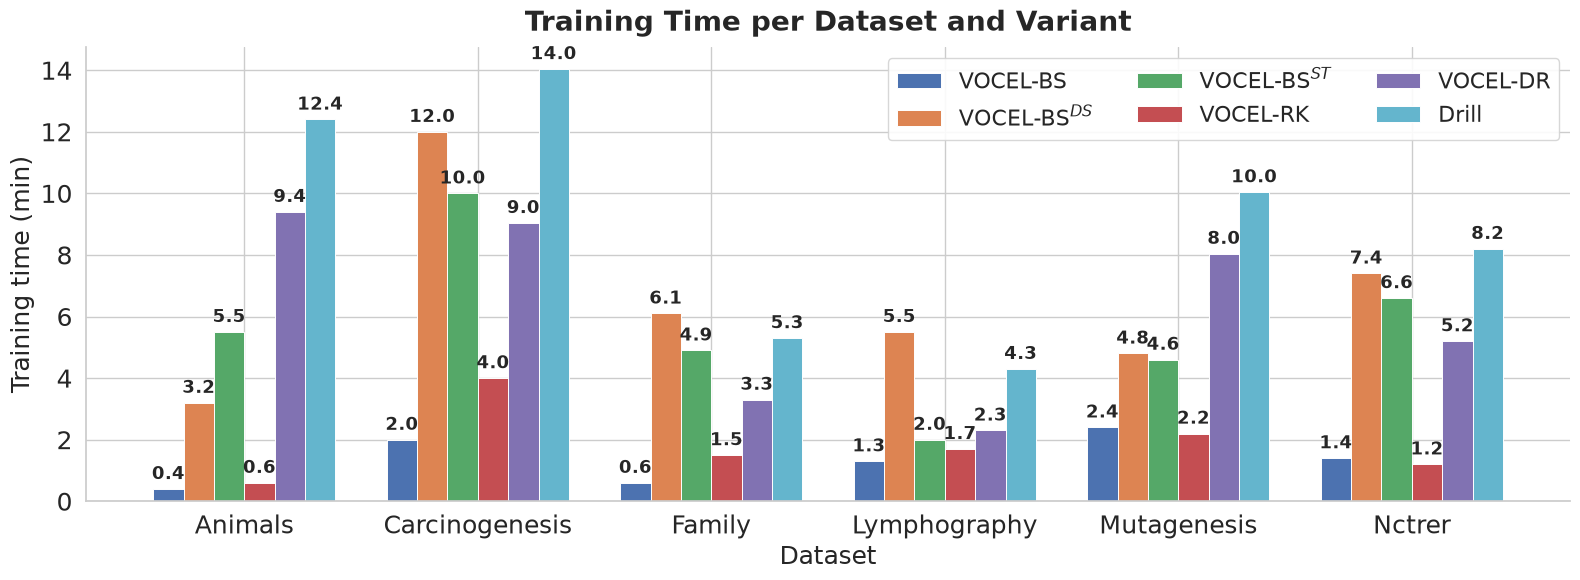

\begin{table}[t]
\centering
\caption{Training time (minutes) per dataset and method. \textsc{Vocel} variants: one epoch timed, multiplied by the total epoch count. Drill: one RL learning problem timed, multiplied by 10 LPs.}
\label{tab:training_time}
\begin{tabular}{lrrrrrr}
\toprule
Dataset & \textsc{Vocel}-BS & \textsc{Vocel}-BS$^{\textsc{ds}}$ & \textsc{Vocel}-BS$^{\textsc{st}}$ & \textsc{Vocel}-RK & \textsc{Vocel}-DR & Drill \\
\midrule
Animals & 0.4 & 3.2 & 5.5 & 0.6 & 9.4 & 12.4 \\
Carcinogenesis & 2.0 & 12.0 & 10.0 & 4.0 & 9.0 & 14.0 \\
Family & 0.6 & 6.1 & 4.9 & 1.5 & 3.3 & 5.3 \\
Lymphography & 1.3 & 5.5 & 2.0 & 1.7 & 2.3 & 4.3 \\
Mutagenesis & 2.4 & 4.8 & 4.6 & 2.2 & 8.0 & 10.0 \\
Nctrer & 1.4 & 7.4 & 6.6 & 1.2 & 5.2 & 8.2 \\
\bottomrule
\end{tabular}
\end{table}


In [4]:

# ── Hardcoded training time data ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Display labels used in the plot (matplotlib mathtext for superscripts)
LBL_BS    = r"VOCEL-BS"
LBL_BS_DS = r"VOCEL-BS$^{DS}$"
LBL_BS_ST = r"VOCEL-BS$^{ST}$"
LBL_RK    = r"VOCEL-RK"
LBL_DR    = r"VOCEL-DR"
LBL_DL    = r"Drill"

df_timing = pd.DataFrame([
    # Animals
    dict(ds="Animals",       display=LBL_BS,    total_min=0.4),
    dict(ds="Animals",       display=LBL_BS_DS, total_min=3.2),
    dict(ds="Animals",       display=LBL_BS_ST, total_min=5.5),
    dict(ds="Animals",       display=LBL_RK,    total_min=0.6),
    dict(ds="Animals",       display=LBL_DR,    total_min=9.4),
    dict(ds="Animals",       display=LBL_DL,    total_min=12.4),
    # Carcinogenesis
    dict(ds="Carcinogenesis",display=LBL_BS,    total_min=2.0),
    dict(ds="Carcinogenesis",display=LBL_BS_DS, total_min=12.0),
    dict(ds="Carcinogenesis",display=LBL_BS_ST, total_min=10.0),
    dict(ds="Carcinogenesis",display=LBL_RK,    total_min=4.0),
    dict(ds="Carcinogenesis",display=LBL_DR,    total_min=9.04),
    dict(ds="Carcinogenesis",display=LBL_DL,    total_min=14.04),
    # Family
    dict(ds="Family",        display=LBL_BS,    total_min=0.6),
    dict(ds="Family",        display=LBL_BS_DS, total_min=6.1),
    dict(ds="Family",        display=LBL_BS_ST, total_min=4.9),
    dict(ds="Family",        display=LBL_RK,    total_min=1.5),
    dict(ds="Family",        display=LBL_DR,    total_min=3.3),
    dict(ds="Family",        display=LBL_DL,    total_min=5.3),
    # Lymphography
    dict(ds="Lymphography",  display=LBL_BS,    total_min=1.3),
    dict(ds="Lymphography",  display=LBL_BS_DS, total_min=5.5),
    dict(ds="Lymphography",  display=LBL_BS_ST, total_min=2.0),
    dict(ds="Lymphography",  display=LBL_RK,    total_min=1.7),
    dict(ds="Lymphography",  display=LBL_DR,    total_min=2.3),
    dict(ds="Lymphography",  display=LBL_DL,    total_min=4.3),
    # Mutagenesis
    dict(ds="Mutagenesis",   display=LBL_BS,    total_min=2.4),
    dict(ds="Mutagenesis",   display=LBL_BS_DS, total_min=4.8),
    dict(ds="Mutagenesis",   display=LBL_BS_ST, total_min=4.6),
    dict(ds="Mutagenesis",   display=LBL_RK,    total_min=2.2),
    dict(ds="Mutagenesis",   display=LBL_DR,    total_min=8.04),
    dict(ds="Mutagenesis",   display=LBL_DL,    total_min=10.04),
    # Nctrer
    dict(ds="Nctrer",        display=LBL_BS,    total_min=1.4),
    dict(ds="Nctrer",        display=LBL_BS_DS, total_min=7.4),
    dict(ds="Nctrer",        display=LBL_BS_ST, total_min=6.6),
    dict(ds="Nctrer",        display=LBL_RK,    total_min=1.2),
    dict(ds="Nctrer",        display=LBL_DR,    total_min=5.2),
    dict(ds="Nctrer",        display=LBL_DL,    total_min=8.2),
])

# ── Layout ────────────────────────────────────────────────────────────────────
DS_ORDER  = ["Animals","Carcinogenesis","Family","Lymphography","Mutagenesis","Nctrer"]
COL_ORDER = [LBL_BS, LBL_BS_DS, LBL_BS_ST, LBL_RK, LBL_DR, LBL_DL]
COLORS    = {
    LBL_BS:    "#4C72B0",
    LBL_BS_DS: "#DD8452",
    LBL_BS_ST: "#55A868",
    LBL_RK:    "#C44E52",
    LBL_DR:    "#8172B2",
    LBL_DL:    "#64B5CD",
}

pivot_time = (df_timing.pivot_table(index="ds", columns="display",
                                    values="total_min", aggfunc="first")
              .reindex(DS_ORDER))
col_order  = [c for c in COL_ORDER if c in pivot_time.columns]
pivot_time = pivot_time[col_order]

# ── Font sizes ────────────────────────────────────────────────────────────────
FBASE   = 18   # axis labels, tick labels, legend
FTITLE  = 20   # title
FANNOT  = 13   # bar value labels

# ── Bar chart ─────────────────────────────────────────────────────────────────
x     = np.arange(len(DS_ORDER))
width = 0.13

fig, ax = plt.subplots(figsize=(16, 6))
for i, col in enumerate(col_order):
    vals = pivot_time[col].values.astype(float)
    bars = ax.bar(x + i*width, vals, width, label=col,
                  color=COLORS.get(col, "gray"), edgecolor="white", linewidth=0.7)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.18,
                    f"{v:.1f}", ha="center", va="bottom",
                    fontsize=FANNOT, fontweight="bold")

ax.set_xticks(x + width * (len(col_order)-1) / 2)
ax.set_xticklabels(DS_ORDER, rotation=0, fontsize=FBASE)
ax.set_ylabel("Training time (min)", fontsize=FBASE)
ax.set_xlabel("Dataset", fontsize=FBASE)
ax.set_title("Training Time per Dataset and Variant", fontsize=FTITLE, fontweight="bold", pad=12)
ax.legend(fontsize=FBASE - 2, ncol=3, loc="upper right",
          framealpha=0.9, edgecolor="lightgray")
ax.tick_params(axis="y", labelsize=FBASE)
for sp in ["top","right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
out_pdf = ROOT / "training_time.pdf"
out_png = ROOT / "training_time.png"

plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_png, bbox_inches="tight")
print(f"Saved → {out_pdf}")
print(f"Saved → {out_png}")
plt.show()

# ── LaTeX table ───────────────────────────────────────────────────────────────
def fmt_min(v):
    if pd.isna(v): return "--"
    return f"{v:.1f}"

col_headers = {
    LBL_BS:    r"\textsc{Vocel}-BS",
    LBL_BS_DS: r"\textsc{Vocel}-BS$^{\textsc{ds}}$",
    LBL_BS_ST: r"\textsc{Vocel}-BS$^{\textsc{st}}$",
    LBL_RK:    r"\textsc{Vocel}-RK",
    LBL_DR:    r"\textsc{Vocel}-DR",
    LBL_DL:    r"Drill",
}

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\caption{Training time (minutes) per dataset and method. "
             r"\textsc{Vocel} variants: one epoch timed, multiplied by the total epoch count. "
             r"Drill: one RL learning problem timed, multiplied by 10 LPs.}")
lines.append(r"\label{tab:training_time}")
lines.append(r"\begin{tabular}{l" + "r"*len(col_order) + "}")
lines.append(r"\toprule")
lines.append("Dataset & " + " & ".join(col_headers[c] for c in col_order) + r" \\")
lines.append(r"\midrule")
for ds in DS_ORDER:
    row_vals = [fmt_min(pivot_time.loc[ds, c]) if c in pivot_time.columns else "--"
                for c in col_order]
    lines.append(f"{ds} & " + " & ".join(row_vals) + r" \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

print("\n".join(lines))
